# Wheat Futures Return Prediction — Regional Per-Region Approach

**Objective:** Predict 5-day forward returns on Milling Wheat N2 futures using per-region
agricultural data from CY-Bench, following the regional modelling methodology of
Paudel et al. (2022).

**Key Design Choices (following Paudel et al. 2022 & Thaker et al. 2024):**

1. **One model per region** — each NUTS-level region in FR, DE, PL gets its own regression
   model trained on that region's agricultural features + shared price features. This avoids
   aggregation errors that accumulate when predictors are averaged across heterogeneous
   regions (Paudel et al. 2022, Section 1).
2. **Region selection** — not all regions are informative. Adding too many regions can
   degrade performance (Thaker et al. 2024, Figure 5). We apply both forward and backward
   stepwise selection with the one-standard-error rule (MA429 Lecture 3) to select the
   most predictive subset.
3. **Production-weighted aggregation** — per-region predictions are aggregated to EU-level
   using crop-area/production weights (Paudel et al. 2022, Section 2.5.3; Cerrani &
   López Lozano, 2017).
4. **Four model families** — Ridge, Lasso, Gradient Boosted Trees, Random Forest
   (representing linear regularised, sparse linear, and two ensemble methods).
5. **Regression target** — continuous 5-day forward return (not classification).

**Period:** 2003–2023 | **Data:** Euronext Milling Wheat N2 + CY-Bench (FR, DE, PL)

In [1]:
import pandas as pd
import numpy as np
import os
import glob
import warnings
from datetime import timedelta

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print("All imports successful.")

All imports successful.


---
## 1. Load and Prepare Futures Price Data

In [2]:
# ============================================================
# CONFIGURATION
# ============================================================
FUTURES_PATH = "CA1 Commodity Historical Data v2.xlsx"
CYBENCH_DATA_DIR = "cy-bench"

FORECAST_HORIZON = 5   # 5 trading days (1 week) forward return
AG_LAG_DAYS = 0        # No artificial lag: futures traders react in real time

# ============================================================
# Load futures data
# ============================================================
futures_raw = pd.read_excel(FUTURES_PATH, na_values=['#N/A N/A', '#N/A', 'N/A'])
futures_raw = futures_raw.drop(columns=[c for c in futures_raw.columns 
                                         if 'Unnamed' in str(c) or 'Setting' in str(c)],
                                errors='ignore')
print(f"Raw futures data shape: {futures_raw.shape}")
futures_raw.head()

Raw futures data shape: (6968, 16)


,Date,PX_LAST,PX_BID,OPEN_INT,PX_OPEN,PX_HIGH,PX_LOW,PX_VOLUME,PX_LAST_ADJ,PX_BID_ADJ,OPEN_INT_ADJ,PX_OPEN_ADJ,PX_HIGH_ADJ,PX_LOW_ADJ,PX_VOLUME_ADJ,ROLL
0,2026-03-02,201.25,201.00,NaN,203.75,204.25,200.50,85071.0,201.25,201.00,NaN,203.75,204.25,200.50,85071.0,1.001244
1,2026-02-27,197.50,193.75,9694.0,193.50,197.75,193.50,12930.0,201.50,197.67,9694.0,197.42,201.76,197.42,12930.0,0.999140
2,2026-02-26,193.25,192.00,15198.0,193.25,194.50,192.25,12908.0,197.16,195.89,15198.0,197.16,198.44,196.14,12908.0,0.986523
3,2026-02-25,193.00,192.50,19460.0,195.50,195.75,192.50,15145.0,196.91,196.40,19460.0,199.46,199.71,196.40,15145.0,0.982688
4,2026-02-24,195.25,195.00,25540.0,195.50,197.25,195.00,20632.0,199.20,198.95,25540.0,199.46,201.24,198.95,20632.0,0.981402


In [3]:
# Parse and clean futures data
futures = futures_raw.copy()
futures['Date'] = pd.to_datetime(futures['Date'], format='%m/%d/%Y')
futures = futures.sort_values('Date').reset_index(drop=True)

# Use adjusted columns
futures['Price'] = futures['PX_LAST_ADJ']
futures['Open'] = futures['PX_OPEN_ADJ']
futures['High'] = futures['PX_HIGH_ADJ']
futures['Low'] = futures['PX_LOW_ADJ']
futures['Volume'] = futures['PX_VOLUME_ADJ']

# Filter to 2003-2023
futures = futures[
    (futures['Date'] >= '2002-12-31') & (futures['Date'] <= '2023-12-31')
].copy()

futures = futures[['Date', 'Price', 'Open', 'High', 'Low', 'Volume']]
futures['Volume'] = futures['Volume'].ffill()
futures = futures.dropna(subset=['Price']).reset_index(drop=True)

print(f"Futures data: {futures.shape[0]} trading days from "
      f"{futures['Date'].min().date()} to {futures['Date'].max().date()}")
futures.head()

Futures data: 5389 trading days from 2002-12-31 to 2023-12-29


,Date,Price,Open,High,Low,Volume
0,2002-12-31,76.15,76.15,76.15,76.15,2.0
1,2003-01-02,76.15,76.15,76.15,76.15,38.0
2,2003-01-03,76.15,76.15,76.15,76.15,4.0
3,2003-01-06,76.15,76.15,76.15,76.15,5.0
4,2003-01-07,75.31,75.98,75.98,75.31,97.0


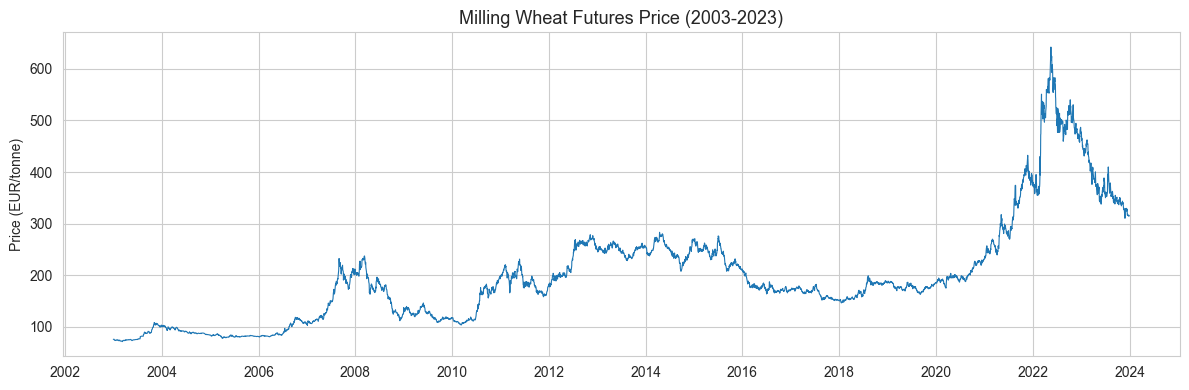

In [7]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(futures['Date'], futures['Price'], linewidth=0.8)
ax.set_title('Milling Wheat Futures Price (2003-2023)', fontsize=13)
ax.set_ylabel('Price (EUR/tonne)')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

---
## 2. Create Target Variable and Price-Only Features

In [5]:
# ============================================================
# Target: continuous 5-day forward return (regression)
# ============================================================
futures['Fwd_Return'] = futures['Price'].shift(-FORECAST_HORIZON) / futures['Price'] - 1

# ============================================================
# MINIMAL price features: returns + volume only
#
# We deliberately strip price features to the bare minimum.
# The goal is to isolate whether AGRICULTURAL data from
# CY-Bench adds predictive signal, not to build the best
# possible price-based model. If we included RSI, SMAs,
# Bollinger bands etc., any lift from ag features could be
# confounded with price feature interactions.
#
# We keep only:
#   - ret_5d: 1-week momentum (same horizon as target)
#   - ret_20d: 1-month momentum (medium-term trend)
#   - vol_sma_ratio: relative volume (liquidity/attention)
#
# These 3 features form a minimal "market state" control.
# ============================================================

futures['ret_5d'] = futures['Price'].pct_change(5)
futures['ret_20d'] = futures['Price'].pct_change(20)
futures['vol_sma_ratio'] = futures['Volume'] / futures['Volume'].rolling(20).mean()

price_feature_cols = ['ret_5d', 'ret_20d', 'vol_sma_ratio']
print(f"Price features ({len(price_feature_cols)}): {price_feature_cols}")

Price features (3): ['ret_5d', 'ret_20d', 'vol_sma_ratio']


---
## 3. Load CY-Bench Agricultural Data (FR, DE, PL)

We load data for all three major EU wheat producers. Unlike the previous version
which aggregated regions immediately, here we **keep each region separate** —
each region will become a candidate for per-region modelling.

In [15]:
# ============================================================
# Generic CY-Bench loader for any country
# ============================================================

def load_cybench_csv(directory, pattern):
    matches = glob.glob(os.path.join(directory, pattern))
    if not matches:
        return None
    df = pd.read_csv(matches[0])
    return df

def load_country_data(country_code, cybench_dir):
    """
    Load all CY-Bench CSVs for a given country code.
    Returns dict of DataFrames keyed by data type.
    """
    possible = [
        os.path.join(cybench_dir, country_code),
        os.path.join(cybench_dir, 'EU'),
        cybench_dir,
    ]
    data_dir = None
    for p in possible:
        if os.path.isdir(p):
            pattern = f'meteo_wheat_{country_code}.csv'
            if glob.glob(os.path.join(p, pattern)):
                data_dir = p
                break

    if data_dir is None:
        print(f"  {country_code}: Data not found, skipping.")
        return None

    print(f"  {country_code}: Loading from {data_dir}")
    datasets = {}
    for var, pat in [('meteo', f'meteo_wheat_{country_code}.csv'),
                     ('soil_moisture', f'soil_moisture_wheat_{country_code}.csv'),
                     ('ndvi', f'ndvi_wheat_{country_code}.csv'),
                     ('fpar', f'fpar_wheat_{country_code}.csv')]:
        df = load_cybench_csv(data_dir, pat)
        if df is not None:
            # Filter to country regions
            if 'adm_id' in df.columns:
                df = df[df['adm_id'].astype(str).str.startswith(country_code)].copy()
            datasets[var] = df
            print(f"    {var}: {df.shape}, {df['adm_id'].nunique()} regions")

    # Load yield data for production weights
    yield_df = load_cybench_csv(data_dir, f'yield_wheat_{country_code}.csv')
    if yield_df is not None and 'adm_id' in yield_df.columns:
        yield_df = yield_df[yield_df['adm_id'].astype(str).str.startswith(country_code)].copy()
        datasets['yield'] = yield_df
        print(f"    yield: {yield_df.shape}, {yield_df['adm_id'].nunique()} regions")

    return datasets

# Load all three countries
print("Loading CY-Bench agricultural data\n")
country_data = {}

# DK not included because yield data starts in 2006
# countries = ['FR', 'DE', 'PL', 'RO', 'BG', 'LT', 'CZ', 'ES']
# countries = ['FR', 'DE', 'PL', 'RO', 'BG']
# countries = ['FR', 'DE', 'PL']
# countries = ['DK', 'IE']
countries = ['FR']

for country in countries:
    data = load_country_data(country, CYBENCH_DATA_DIR)
    if data is not None:
        country_data[country] = data
    print()

print(f"Countries loaded: {list(country_data.keys())}")
for country, data in country_data.items():
    n_regions = set()
    for k, df in data.items():
        if 'adm_id' in df.columns:
            n_regions.update(df['adm_id'].unique())
    print(f"  {country}: {len(n_regions)} unique regions, data types: {list(data.keys())}")

Loading CY-Bench agricultural data

  FR: Loading from cy-bench\FR
    meteo: (814800, 11), 97 regions
    soil_moisture: (740886, 5), 97 regions
    ndvi: (97951, 4), 97 regions
    fpar: (80316, 4), 97 regions
    yield: (2571, 7), 95 regions

Countries loaded: ['FR']
  FR: 98 unique regions, data types: ['meteo', 'soil_moisture', 'ndvi', 'fpar', 'yield']


---
## 4. Process Agricultural Data: Per-Region Daily Expansion

**Critical difference from the aggregated approach:** We do NOT average across
regions. Instead, for each region we:

1. Parse the date column (YYYYMMDD string)
2. Forward-fill to daily frequency (LOCF — last observation carried forward)
3. Keep the region identifier so we can build per-region models later

This follows Paudel et al. (2022, Section 2): "Machine learning models were built
per crop and country, i.e. data for all regions within a country were pooled to
build a model for that country."

However, we go further: we build **one model per region** and then aggregate
predictions, which Chipanshi et al. (2015) showed produces better results than
aggregating predictors first (cited in Paudel et al. 2022, Section 1).

In [16]:
# ============================================================
# Step 4a: Build production weights per region
#
# Production weights serve TWO purposes:
#   1. Aggregating per-region predictions to EU level
#      (Paudel et al. 2022, Section 2.5.3)
#   2. Informing which regions matter economically
#
# We use PREVIOUS year's production to avoid look-ahead bias.
#
# HANDLING INCOMPLETE DATA (Germany):
#   Germany's CY-Bench data has:
#     - yield:        available every year
#     - harvest_area: available only every ~4 years (census)
#     - production:   entirely NaN
#   France/Poland have all three columns filled.
#
#   Solution (following user specification):
#     1. Forward-fill harvest_area within each region
#        (area changes slowly between censuses)
#     2. Compute production = yield * harvest_area
#   This is standard practice: Eurostat publishes area data
#   less frequently than yield, and interpolation/carry-forward
#   is the norm in operational systems (Cerrani & López Lozano,
#   2017).
#
# HANDLING SHORT TIME SERIES:
#   Some regions stop reporting before 2023 (e.g., France stops
#   at 2020, some German regions earlier). We use the most
#   recent available production as fallback.
# ============================================================

production_weights = {}  # {adm_id: {year: production_tonnes}}

for cc, data in country_data.items():
    if 'yield' not in data:
        continue
    ydf = data['yield'].copy()

    # Ensure columns exist
    if 'yield' not in ydf.columns:
        continue

    # --- Handle missing harvest_area and production ---
    # Check which area column exists (FR uses 'harvest_area', DE also)
    area_col = None
    for candidate in ['harvest_area', 'planted_area']:
        if candidate in ydf.columns:
            area_col = candidate
            break

    if area_col is not None:
        # Forward-fill harvest_area within each region
        # (area changes slowly; census every ~4 years for DE)
        ydf = ydf.sort_values(['adm_id', 'harvest_year'])
        ydf[area_col] = ydf.groupby('adm_id')[area_col].ffill()
        # Also backward-fill to cover years before first census
        ydf[area_col] = ydf.groupby('adm_id')[area_col].bfill()

    # Compute production where missing
    if 'production' not in ydf.columns:
        ydf['production'] = np.nan

    missing_prod = ydf['production'].isna()
    if missing_prod.any() and area_col is not None:
        ydf.loc[missing_prod, 'production'] = (
            ydf.loc[missing_prod, 'yield'] * ydf.loc[missing_prod, area_col]
        )
        n_filled = missing_prod.sum() - ydf['production'].isna().sum()
        print(f"  {cc}: Filled {n_filled} missing production values "
              f"(yield * forward-filled {area_col})")

    # Remaining NaN in production (no area data at all)
    still_missing = ydf['production'].isna().sum()
    if still_missing > 0:
        print(f"  {cc}: {still_missing} rows still missing production "
              f"(no area data available)")

    # Build the weights dictionary
    for _, row in ydf.iterrows():
        adm = row['adm_id']
        yr = row['harvest_year']
        prod = row['production']
        if pd.notna(prod) and prod > 0:
            if adm not in production_weights:
                production_weights[adm] = {}
            production_weights[adm][yr] = prod

    n_regions = len([r for r in production_weights if r.startswith(cc)])
    print(f"  {cc}: {n_regions} regions with production weights")

print(f"\nTotal regions with production weights: {len(production_weights)}")
for cc in country_data:
    cc_regions = [r for r in production_weights if r.startswith(cc)]
    if cc_regions:
        # Show year coverage
        all_years = set()
        for r in cc_regions:
            all_years.update(production_weights[r].keys())
        print(f"  {cc}: {len(cc_regions)} regions, "
              f"years {min(all_years)}-{max(all_years)}")

# Helper: get production weight for a region in a given year
# Uses previous year's production (lag 1 year to avoid look-ahead)
def get_production_weight(adm_id, year):
    if adm_id not in production_weights:
        return 0.0
    prev_year = year - 1
    if prev_year in production_weights[adm_id]:
        return production_weights[adm_id][prev_year]
    # Fallback: use nearest earlier available year
    available = sorted(production_weights[adm_id].keys())
    earlier = [y for y in available if y < year]
    if earlier:
        return production_weights[adm_id][earlier[-1]]
    # Last resort: use earliest available
    if available:
        return production_weights[adm_id][available[0]]
    return 0.0

  FR: 95 regions with production weights

Total regions with production weights: 95
  FR: 95 regions, years 1989-2020


# ============================================================
# Step 4b: Process time-series data PER REGION
#
# For each region, we:
#   1. Parse dates
#   2. Combine all data types (meteo, soil, ndvi, fpar)
#   3. Forward-fill to daily frequency
#   4. Store as {adm_id: DataFrame}
#
# NO cross-regional aggregation at this stage.
# ============================================================

def process_region_timeseries(df, name):
    """Parse dates and identify variable columns."""
    if df is None or df.empty:
        return None
    df = df.copy()
    meta_cols = {'adm_id', 'crop_name', 'country_code', 'date',
                 'harvest_year', 'yield', 'harvest_area', 'production',
                 'sos', 'eos', 'crop_area', 'crop_area_percentage',
                 'region_area', 'geometry'}
    var_cols = [c for c in df.columns if c not in meta_cols]
    if 'date' not in df.columns:
        return None
    df['date'] = pd.to_datetime(df['date'], format='%Y%m%d', errors='coerce')
    df = df.dropna(subset=['date'])
    for c in var_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    return df[['adm_id', 'date'] + var_cols], var_cols

def build_region_daily(datasets, country_code):
    """
    Build per-region daily DataFrames from CY-Bench data.
    Returns dict: {adm_id: DataFrame with date + variable columns}
    """
    # Process each data type
    processed = {}
    for dtype in ['meteo', 'soil_moisture', 'ndvi', 'fpar']:
        if dtype not in datasets:
            continue
        result = process_region_timeseries(datasets[dtype], f"{country_code}_{dtype}")
        if result is not None:
            df, var_cols = result
            # Prefix variable names with dtype
            rename = {c: f'{dtype}_{c}' for c in var_cols}
            df = df.rename(columns=rename)
            processed[dtype] = df

    if not processed:
        return {}

    # Get all regions across data types
    all_regions = set()
    for df in processed.values():
        all_regions.update(df['adm_id'].unique())

    # Build per-region combined DataFrames
    region_dfs = {}
    for region in sorted(all_regions):
        dfs_for_region = []
        for dtype, df in processed.items():
            rdf = df[df['adm_id'] == region].drop(columns=['adm_id']).copy()
            if len(rdf) == 0:
                continue
            rdf = rdf.sort_values('date')
            dfs_for_region.append(rdf)

        if not dfs_for_region:
            continue

        # Merge all data types on date
        combined = dfs_for_region[0]
        for df in dfs_for_region[1:]:
            combined = combined.merge(df, on='date', how='outer')
        combined = combined.sort_values('date')

        # Expand to daily with LOCF
        full_dates = pd.date_range(combined['date'].min(),
                                    combined['date'].max(), freq='D')
        combined = combined.set_index('date').reindex(full_dates).ffill()
        combined = combined.reset_index().rename(columns={'index': 'date'})

        region_dfs[region] = combined

    return region_dfs


# Build per-region daily data for all countries
print("Building per-region daily datasets...\n")
all_region_dfs = {}  # {adm_id: DataFrame}

for cc, data in country_data.items():
    region_dfs = build_region_daily(data, cc)
    all_region_dfs.update(region_dfs)
    print(f"  {cc}: {len(region_dfs)} regions processed")
    if region_dfs:
        sample_region = list(region_dfs.keys())[0]
        sample_df = region_dfs[sample_region]
        n_feats = len([c for c in sample_df.columns if c != 'date'])
        print(f"    Sample region {sample_region}: {sample_df.shape[0]} days, "
              f"{n_feats} features")
        print(f"    Date range: {sample_df['date'].min().date()} to "
              f"{sample_df['date'].max().date()}")

print(f"\nTotal regions across all countries: {len(all_region_dfs)}")

# ============================================================
# Save per-region daily data to CSV
#
# One CSV per region: {adm_id}_daily.csv
# Also save a summary index CSV listing all regions.
# ============================================================

REGION_DATA_DIR = "region_daily_data"
os.makedirs(REGION_DATA_DIR, exist_ok=True)

summary_rows = []
for adm_id, df in sorted(all_region_dfs.items()):
    path = os.path.join(REGION_DATA_DIR, f"{adm_id}_daily.csv")
    df.to_csv(path, index=False)
    n_feats = len([c for c in df.columns if c != 'date'])
    summary_rows.append({
        'adm_id': adm_id,
        'country': adm_id[:2],
        'n_days': len(df),
        'n_features': n_feats,
        'date_min': df['date'].min().date(),
        'date_max': df['date'].max().date(),
    })

summary = pd.DataFrame(summary_rows)
summary.to_csv(os.path.join(REGION_DATA_DIR, "_region_index.csv"), index=False)

print(f"Saved {len(summary)} region CSVs to '{REGION_DATA_DIR}/'")
print(f"Index file: {REGION_DATA_DIR}/_region_index.csv\n")
print(summary.groupby('country').agg(
    regions=('adm_id', 'count'),
    avg_days=('n_days', 'mean'),
    avg_features=('n_features', 'mean'),
).to_string())

import pandas as pd
import os

REGION_DATA_DIR = "region_daily_data"

rows = []
for fname in sorted(os.listdir(REGION_DATA_DIR)):
    if fname.startswith('_') or not fname.endswith('_daily.csv'):
        continue
    adm_id = fname.replace('_daily.csv', '')
    df = pd.read_csv(os.path.join(REGION_DATA_DIR, fname), parse_dates=['date'])
    n_feats = len([c for c in df.columns if c != 'date'])
    rows.append({
        'adm_id': adm_id,
        'country': adm_id[:2],
        'n_days': len(df),
        'n_features': n_feats,
        'date_min': df['date'].min().date(),
        'date_max': df['date'].max().date(),
    })

index_df = pd.DataFrame(rows)
index_df.to_csv(os.path.join(REGION_DATA_DIR, "_region_index.csv"), index=False)

print(f"Rebuilt index: {len(index_df)} regions")
print(index_df.groupby('country')['adm_id'].count().to_string())

In [17]:
# ============================================================
# Load pre-generated per-region daily CSVs
#
# Skips: CY-Bench loading, parsing, daily expansion, saving
# Requires: the region_daily_data/ folder from a previous run
# Only loads regions from countries in the countries list.
# ============================================================

REGION_DATA_DIR = "region_daily_data"

# --- Load region index ---
index_path = os.path.join(REGION_DATA_DIR, "_region_index.csv")
region_index = pd.read_csv(index_path)
print(f"Found {len(region_index)} total regions in '{REGION_DATA_DIR}/'")

# --- Filter to countries list ---
region_index = region_index[region_index['country'].isin(countries)]
print(f"After filtering to {countries}: {len(region_index)} regions")

# --- Load region CSVs into all_region_dfs ---
all_region_dfs = {}
for _, row in region_index.iterrows():
    adm_id = row['adm_id']
    path = os.path.join(REGION_DATA_DIR, f"{adm_id}_daily.csv")
    df = pd.read_csv(path, parse_dates=['date'])
    all_region_dfs[adm_id] = df

print(f"Loaded {len(all_region_dfs)} regions")
print(f"countries: {region_index.groupby('country')['adm_id'].count().to_dict()}")

Found 659 total regions in 'region_daily_data/'
After filtering to ['FR']: 97 regions
Loaded 97 regions
countries: {'FR': 97}


---
## 4c. Per-Region Feature Engineering

Following CY-Bench (Paudel et al., 2025, Section 2.2.3) recommendations:
*"time series data are aggregated in the temporal dimension to create
domain-relevant features... monthly averages of tmin, tmax, tavg, prec,
cumulative CWB... monthly maximum values for cumulative GDD, cumul prec,
cumul fPAR, cumul NDVI... number of cold days, hot days, dry days."*

We apply these feature transformations to EACH region individually before
any cross-regional aggregation. This preserves region-specific signals
(e.g., drought in Beauce vs normal conditions in Brittany) that would be
lost if we aggregated raw features first.

In [18]:
# ============================================================
# Per-region feature engineering
#
# For each region's daily DataFrame, we compute:
#   1. Rolling means and cumulative sums (30d, 60d windows)
#   2. Threshold-based stress indicators (CY-Bench: cold/hot/dry days)
#   3. NDVI/fPAR anomalies (relative to expanding DOY climatology)
#   4. Phenological phase indicators (based on month)
#   5. Cross-variable interactions (VPD stress, DTR)
#
# CY-Bench Section 2.2.3: "Following expert recommendations we create
# monthly averages... cumulative growing degree days, cumulative
# precipitation, cumulative fPAR and cumulative NDVI... number of days
# in which tmin < 0 ('cold days'), tmax > 35 ('hot days'), prec < 1mm
# ('dry days')."
# ============================================================

def engineer_region_features(df):
    """
    Apply feature engineering to a single region's daily DataFrame.
    Input: DataFrame with 'date' column and raw CY-Bench variables.
    Output: DataFrame with original + engineered features.
    """
    df = df.copy().sort_values('date').set_index('date')
    month = df.index.month

    # ============================================================
    # A. PHENOLOGICAL PHASE INDICATORS
    # Binary flags for which crop phase we're in.
    # French winter wheat phenology:
    #   Sowing → Emergence: Oct-Nov
    #   Dormancy / Vernalisation: Dec-Feb
    #   Stem elongation: Mar-Apr
    #   Heading / Flowering: May
    #   Grain filling: Jun-Jul
    # ============================================================
    df['in_growing_season'] = ((month >= 10) | (month <= 7)).astype(float)
    df['phase_dormant'] = ((month >= 12) | (month <= 2)).astype(float)
    df['phase_stem_elong'] = ((month >= 3) & (month <= 4)).astype(float)
    df['phase_flowering'] = (month == 5).astype(float)
    df['phase_grain_fill'] = ((month >= 6) & (month <= 7)).astype(float)

    # ============================================================
    # B. PHASE-CONDITIONAL STRESS FEATURES
    # These only accumulate stress during vulnerable windows.
    # ============================================================

    # --- Vernalisation frost stress (Dec-Feb): days < -10°C ---
    if 'meteo_tmin' in df.columns:
        frost_mask = df['phase_dormant'] * (df['meteo_tmin'] < -10).astype(float)
        df['winterkill_risk_30d'] = frost_mask.rolling(30, min_periods=5).sum()
        df['winterkill_risk_60d'] = frost_mask.rolling(60, min_periods=5).sum()
        # Milder frost days (< -5°C) during dormancy
        mild_frost = df['phase_dormant'] * (df['meteo_tmin'] < -5).astype(float)
        df['frost_days_dormant_60d'] = mild_frost.rolling(60, min_periods=5).sum()

    # --- Spring heat shock (Mar-May): days > 25°C ---
    if 'meteo_tmax' in df.columns:
        spring_heat = ((month >= 3) & (month <= 5)).astype(float) * (df['meteo_tmax'] > 25).astype(float)
        df['spring_heat_days_30d'] = spring_heat.rolling(30, min_periods=5).sum()
        df['spring_heat_days_60d'] = spring_heat.rolling(60, min_periods=5).sum()

    # --- Grain-fill heat stress (May-Jul): days > 30°C ---
    # Schlenker & Roberts (2009): nonlinear temperature effects
    # indicate severe damages to US crop yields
    if 'meteo_tmax' in df.columns:
        gf_heat = ((month >= 5) & (month <= 7)).astype(float) * (df['meteo_tmax'] > 30).astype(float)
        df['grainfill_heat_days_30d'] = gf_heat.rolling(30, min_periods=5).sum()
        # Cumulative excess heat above 30°C during grain fill
        gf_excess = ((month >= 5) & (month <= 7)).astype(float) * (df['meteo_tmax'] - 30).clip(lower=0)
        df['grainfill_excess_heat_30d'] = gf_excess.rolling(30, min_periods=5).sum()

    # --- CY-Bench threshold indicators (Paudel et al. 2025, §2.2.3) ---
    # "number of days tmin < 0°C ('cold days'), tmax > 35°C ('hot days'),
    #  prec < 1mm ('dry days')"
    if 'meteo_tmin' in df.columns:
        df['cold_days_30d'] = (df['meteo_tmin'] < 0).astype(float).rolling(30, min_periods=5).sum()
    if 'meteo_tmax' in df.columns:
        df['hot_days_30d'] = (df['meteo_tmax'] > 35).astype(float).rolling(30, min_periods=5).sum()
    if 'meteo_prec' in df.columns:
        df['dry_days_30d'] = (df['meteo_prec'] < 1).astype(float).rolling(30, min_periods=5).sum()

    # --- Flowering drought (Apr-Jun): cumul water deficit ---
    if 'meteo_cwb' in df.columns:
        flower_cwb = df['meteo_cwb'].copy()
        flower_cwb[~((month >= 4) & (month <= 6))] = 0
        df['flowering_drought_60d'] = flower_cwb.rolling(60, min_periods=5).sum()
        df['flowering_drought_90d'] = flower_cwb.rolling(90, min_periods=5).sum()

    # ============================================================
    # C. NDVI ANOMALY - "crop health surprise"
    # How does current NDVI compare to what's normal for this
    # time of year? Low NDVI in Jan = normal (dormant).
    # Low NDVI in May = disaster. We compute the anomaly
    # relative to the historical day-of-year mean.
    # Expanding climatology avoids future leakage.
    # ============================================================
    if 'ndvi_ndvi' in df.columns:
        df['doy'] = df.index.dayofyear
        ndvi_clim = df.groupby('doy')['ndvi_ndvi'].expanding().mean()
        ndvi_clim = ndvi_clim.reset_index(level=0, drop=True).sort_index()
        df['ndvi_anomaly'] = df['ndvi_ndvi'] - ndvi_clim
        df['ndvi_anomaly_30d'] = df['ndvi_anomaly'].rolling(30, min_periods=5).mean()
        df = df.drop(columns=['doy'])

    if 'fpar_fpar' in df.columns:
        df['fpar_doy'] = df.index.dayofyear
        fpar_clim = df.groupby('fpar_doy')['fpar_fpar'].expanding().mean()
        fpar_clim = fpar_clim.reset_index(level=0, drop=True).sort_index()
        df['fpar_anomaly'] = df['fpar_fpar'] - fpar_clim
        df['fpar_anomaly_30d'] = df['fpar_anomaly'].rolling(30, min_periods=5).mean()
        df = df.drop(columns=['fpar_doy'])

    # ============================================================
    # D. COMPACT ROLLING FEATURES
    # 30 and 60-day windows on key variables.
    # CY-Bench (Paudel et al. 2025, §2.2.3): "monthly averages of
    # tmin, tmax, tavg, prec, cumulative CWB... cumulative GDD,
    # cumulative precipitation, cumulative fPAR, cumulative NDVI"
    # ============================================================
    key_vars = [v for v in ['meteo_tavg', 'meteo_tmin', 'meteo_tmax',
                            'meteo_prec', 'meteo_vpd', 'meteo_cwb',
                            'soil_moisture_ssm', 'ndvi_ndvi', 'fpar_fpar']
                if v in df.columns]
    for window in [30, 60]:
        for var in key_vars:
            df[f'{var}_mean_{window}d'] = df[var].rolling(window, min_periods=10).mean()

    # Cumulative precipitation
    if 'meteo_prec' in df.columns:
        for window in [30, 60]:
            df[f'cumul_prec_{window}d'] = df['meteo_prec'].rolling(window, min_periods=10).sum()

    # Growing degree days (base 0°C)
    if 'meteo_tavg' in df.columns:
        gdd_daily = df['meteo_tavg'].clip(lower=0)
        for window in [30, 60]:
            df[f'gdd_cumul_{window}d'] = gdd_daily.rolling(window, min_periods=10).sum()

    # ============================================================
    # E. WEEKEND WEATHER ACCUMULATOR
    # Futures don't trade Sat/Sun but weather happens. On Monday,
    # the market reacts to 3 days of news (Fri evening + weekend).
    # ============================================================
    df['is_monday'] = (df.index.dayofweek == 0).astype(float)
    if 'meteo_prec' in df.columns:
        df['weekend_prec'] = df['meteo_prec'].rolling(3, min_periods=1).sum() * df['is_monday']
    if 'meteo_tmax' in df.columns:
        df['weekend_tmax'] = df['meteo_tmax'].rolling(3, min_periods=1).max() * df['is_monday']
    if 'meteo_tmin' in df.columns:
        df['weekend_tmin'] = df['meteo_tmin'].rolling(3, min_periods=1).min() * df['is_monday']

    # ============================================================
    # F. STANDARDISED PRECIPITATION INDEX (SPI-like)
    # Z-score of rolling precipitation relative to its expanding
    # historical distribution. Positive = wetter than normal,
    # negative = drought.
    # (McKee et al., 1993; widely used in drought monitoring)
    # ============================================================
    if 'meteo_prec' in df.columns:
        for window in [30, 60]:
            roll_prec = df['meteo_prec'].rolling(window, min_periods=10).sum()
            spi_mean = roll_prec.expanding(min_periods=60).mean()
            spi_std = roll_prec.expanding(min_periods=60).std()
            df[f'spi_{window}d'] = (roll_prec - spi_mean) / spi_std.replace(0, np.nan)

    # ============================================================
    # G. DIURNAL TEMPERATURE RANGE (DTR)
    # Large DTR indicates clear skies (drought risk); small DTR
    # indicates cloud cover (rain). Used in crop-climate studies.
    # (Lobell, 2007; Laudien et al., 2023)
    # ============================================================
    if 'meteo_tmax' in df.columns and 'meteo_tmin' in df.columns:
        df['dtr'] = df['meteo_tmax'] - df['meteo_tmin']
        df['dtr_mean_30d'] = df['dtr'].rolling(30, min_periods=10).mean()
        df['dtr_anomaly_30d'] = df['dtr'] - df['dtr'].expanding(min_periods=60).mean()

    # ============================================================
    # H. VPD-BASED DROUGHT STRESS INDEX
    # Vapour pressure deficit is a stronger predictor of crop
    # stress than temperature alone. High VPD = plant stomata
    # close = photosynthesis stops = yield loss.
    # (Lobell et al., 2014; Schlenker & Roberts, 2009)
    # ============================================================
    if 'meteo_vpd' in df.columns:
        vpd_critical = df['meteo_vpd'].copy()
        vpd_critical[~((month >= 3) & (month <= 7))] = 0
        df['vpd_stress_critical_30d'] = vpd_critical.rolling(30, min_periods=5).mean()
        df['vpd_stress_critical_60d'] = vpd_critical.rolling(60, min_periods=5).mean()
        # Days with VPD > 15 hPa (high atmospheric demand)
        df['high_vpd_days_30d'] = (df['meteo_vpd'] > 15).astype(float).rolling(30, min_periods=5).sum()

    # ============================================================
    # I. SOIL MOISTURE DEFICIT INDEX (SMDI-like)
    # Z-score of soil moisture relative to expanding climatology.
    # Negative = drier than normal.
    # (Narasimhan & Srinivasan, 2005)
    # ============================================================
    for sm_var in ['soil_moisture_ssm', 'soil_moisture_rsm']:
        if sm_var in df.columns:
            sm_mean = df[sm_var].expanding(min_periods=60).mean()
            sm_std = df[sm_var].expanding(min_periods=60).std()
            df[f'{sm_var}_zscore'] = (df[sm_var] - sm_mean) / sm_std.replace(0, np.nan)
            df[f'{sm_var}_zscore_30d'] = df[f'{sm_var}_zscore'].rolling(30, min_periods=5).mean()

    # ============================================================
    # J. RADIATION USE EFFICIENCY PROXY
    # FPAR * radiation ≈ absorbed photosynthetically active
    # radiation (APAR). Proxy for biomass accumulation rate.
    # (Monteith, 1972; widely used in crop models)
    # ============================================================
    if 'fpar_fpar' in df.columns and 'meteo_rad' in df.columns:
        df['apar_proxy'] = df['fpar_fpar'] * df['meteo_rad']
        df['apar_proxy_mean_30d'] = df['apar_proxy'].rolling(30, min_periods=10).mean()
        df['apar_doy'] = df.index.dayofyear
        apar_clim = df.groupby('apar_doy')['apar_proxy'].expanding().mean()
        apar_clim = apar_clim.reset_index(level=0, drop=True).sort_index()
        df['apar_anomaly'] = df['apar_proxy'] - apar_clim
        df = df.drop(columns=['apar_doy'])

    # ============================================================
    # K. TEMPERATURE OPTIMALITY INDEX
    # Wheat grows optimally at 15-22°C. We measure how far
    # current conditions deviate from this optimum.
    # (Porter & Gawith, 1999)
    # ============================================================
    if 'meteo_tavg' in df.columns:
        opt_low, opt_high = 15, 22
        temp = df['meteo_tavg']
        df['temp_suboptimal'] = np.where(
            temp < opt_low, opt_low - temp,
            np.where(temp > opt_high, temp - opt_high, 0)
        )
        df['temp_suboptimal_30d'] = df['temp_suboptimal'].rolling(30, min_periods=10).mean()
        # During critical phases only (Mar-Jul)
        subopt_critical = df['temp_suboptimal'].copy()
        subopt_critical[~((month >= 3) & (month <= 7))] = 0
        df['temp_suboptimal_critical_60d'] = subopt_critical.rolling(60, min_periods=10).mean()

    # ============================================================
    # Clean up: drop intermediate masking columns
    # Phase indicators (dormant, stem_elong, flowering) are KEPT
    # as features — they tell the model which crop phase we're in.
    # Only is_monday is dropped (used only for weekend accumulator).
    # ============================================================
    df = df.drop(columns=['is_monday'], errors='ignore')
    df = df.reset_index()

    return df


# Apply to all regions
print("Applying feature engineering to all regions...\n")
n_before = {}
for adm_id, df in all_region_dfs.items():
    n_before[adm_id] = len([c for c in df.columns if c != 'date'])
    all_region_dfs[adm_id] = engineer_region_features(df)

# Report
sample = list(all_region_dfs.keys())[0]
n_after = len([c for c in all_region_dfs[sample].columns if c != 'date'])
print(f"Feature engineering complete for {len(all_region_dfs)} regions")
print(f"  Before: ~{n_before[sample]} features per region")
print(f"  After:  ~{n_after} features per region (+{n_after - n_before[sample]} engineered)")

Applying feature engineering to all regions...

Feature engineering complete for 97 regions
  Before: ~12 features per region
  After:  ~76 features per region (+64 engineered)


Processing correlation matrices for 97 regions...
Total unique features found across all regions: 76


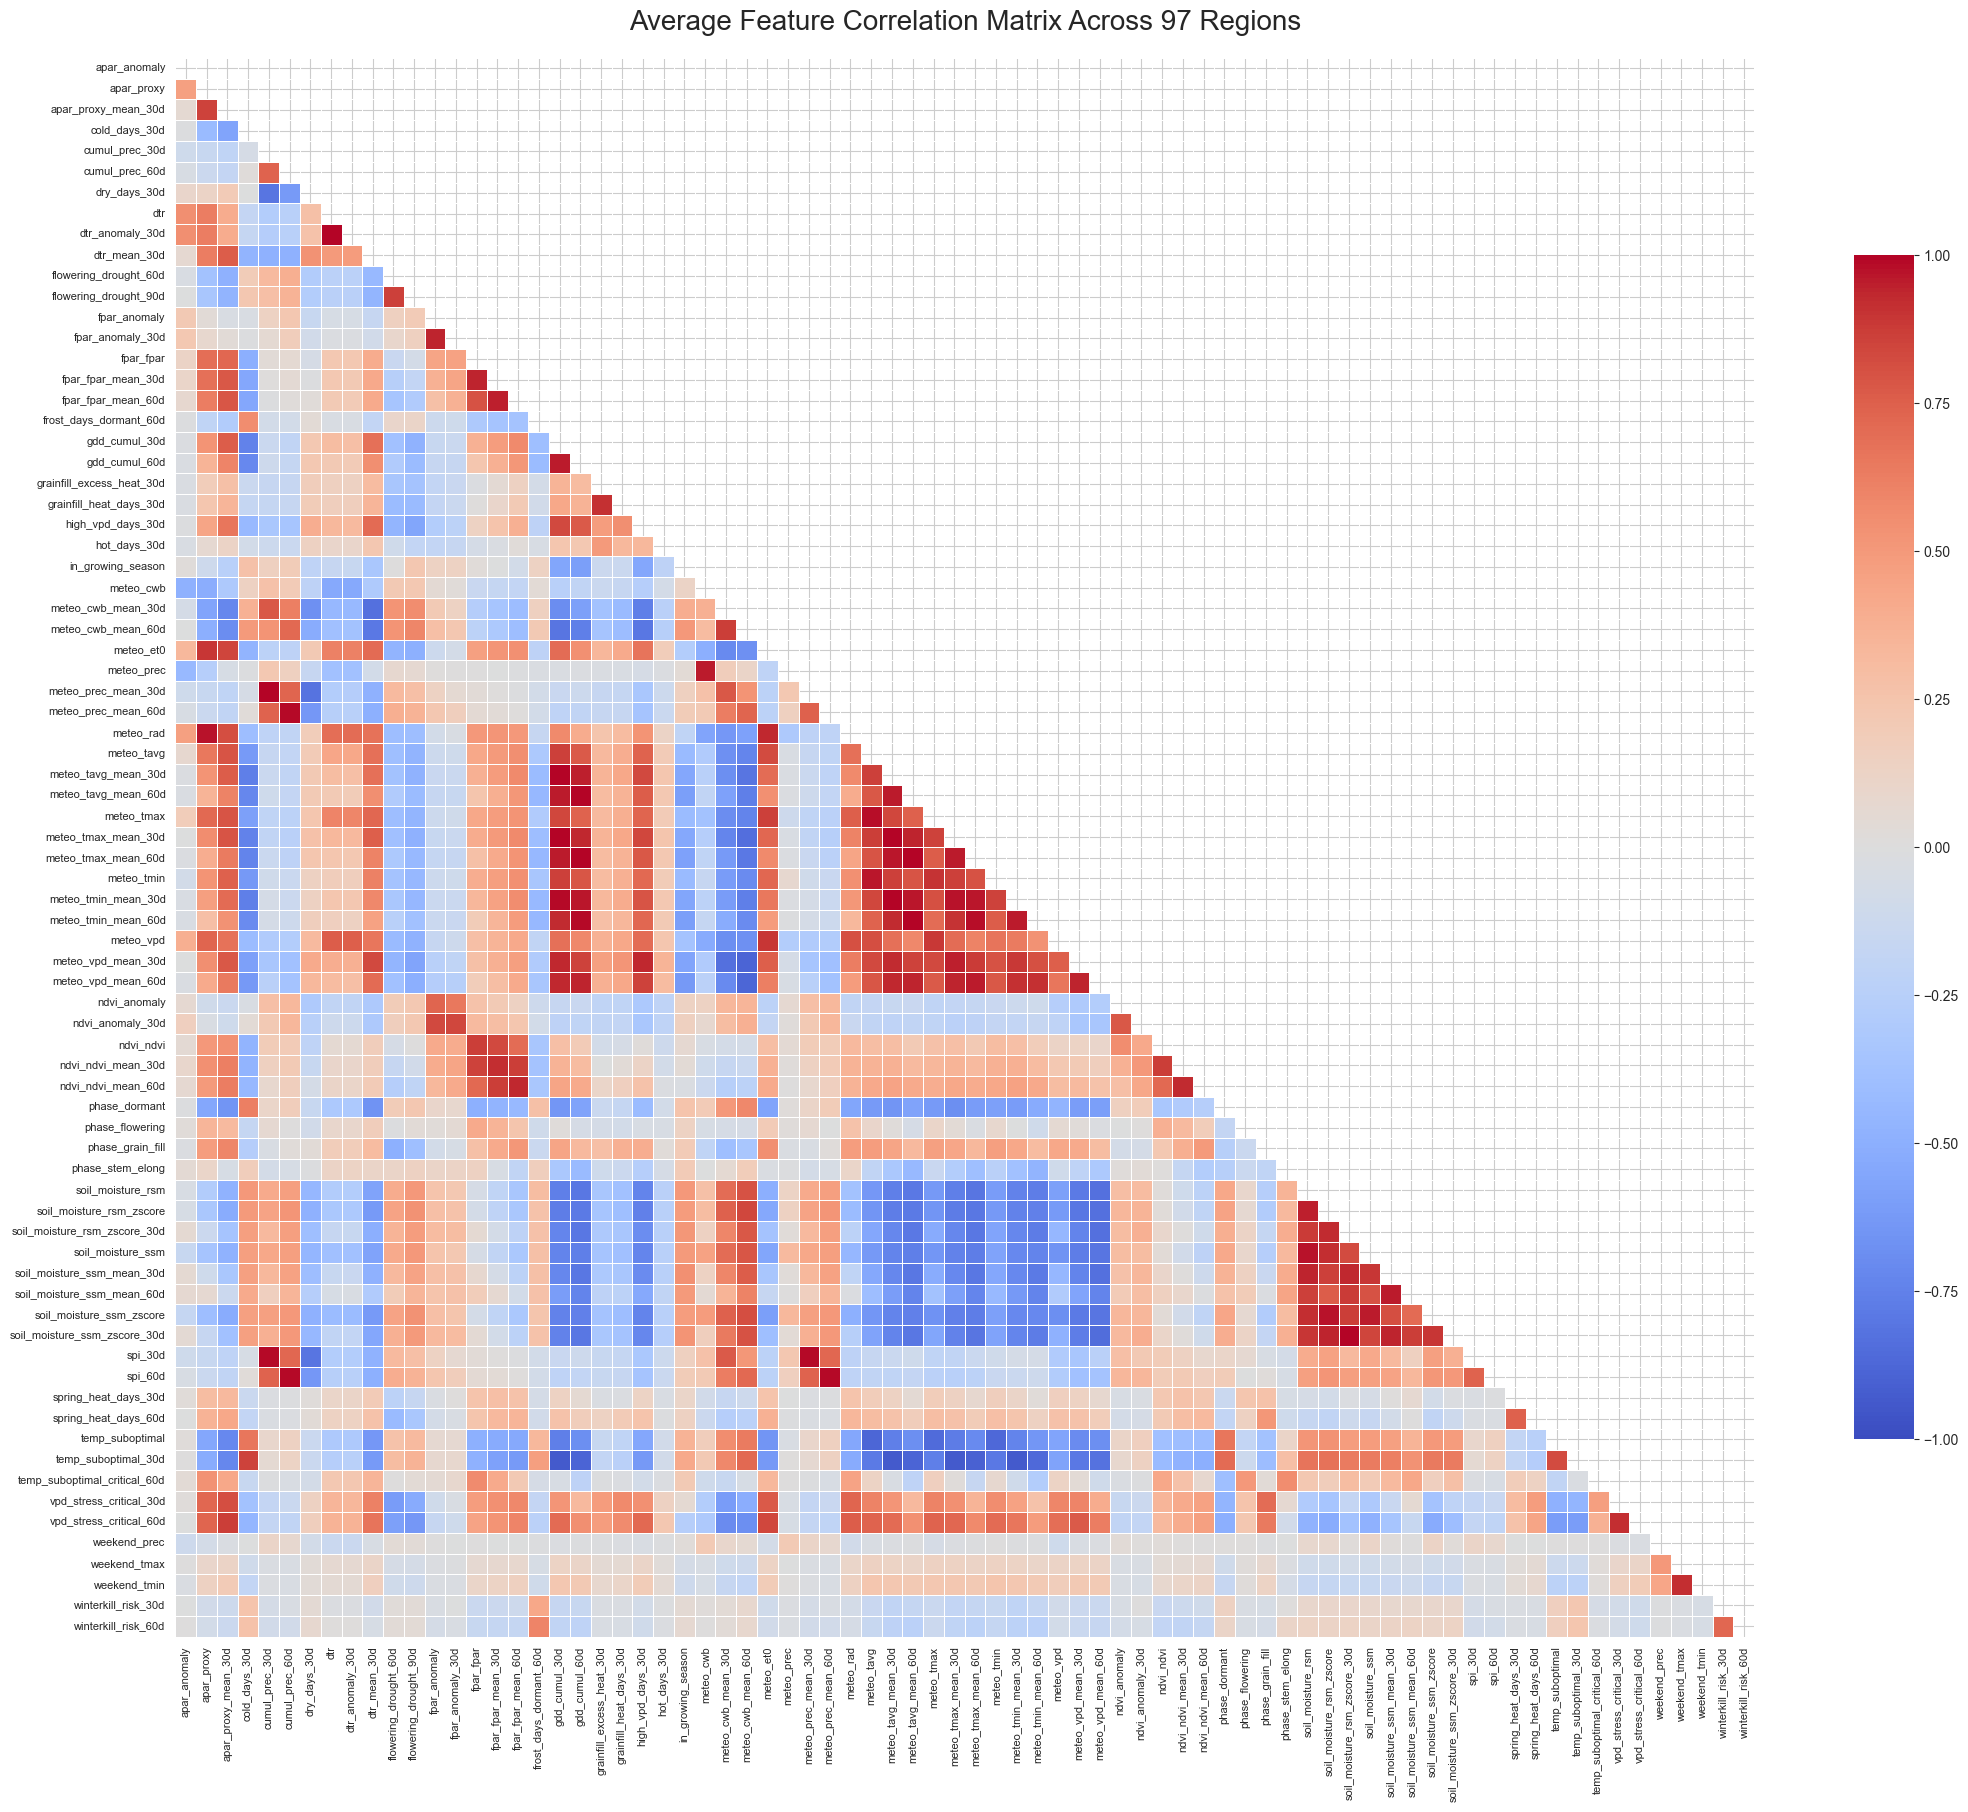

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def compute_average_correlation(region_dfs_dict):
    """
    Computes an average correlation matrix across multiple regions,
    handling missing features dynamically via reindexing.
    """
    fisher_z_matrices = []
    
    print(f"Processing correlation matrices for {len(region_dfs_dict)} regions...")
    
    
    # ------------------------------------------------------------
    # FIX STEP 1: Find the master list of all unique features
    # ------------------------------------------------------------
    master_features = set()
    for df in region_dfs_dict.values():
        cols = df.drop(columns=['date'], errors='ignore').select_dtypes(include=[np.number]).columns
        master_features.update(cols)
        
    master_features = sorted(list(master_features))
    print(f"Total unique features found across all regions: {len(master_features)}")
    
    # ------------------------------------------------------------
    # FIX STEP 2: Standardize all matrices to the master shape
    # ------------------------------------------------------------
    for adm_id, df in region_dfs_dict.items():
        feat_df = df.drop(columns=['date'], errors='ignore').select_dtypes(include=[np.number])
        
        # Calculate raw correlation
        corr = feat_df.corr()
        
        # Force the matrix to be exactly the size of master_features
        # Missing columns/rows become NaN automatically
        corr = corr.reindex(index=master_features, columns=master_features)
        
        # Apply Fisher Z-transform
        corr_vals = corr.values
        # Clip values to avoid infinity from arctanh(1.0), keeping NaNs intact
        corr_clipped = np.where(np.isnan(corr_vals), np.nan, np.clip(corr_vals, -0.9999, 0.9999))
        fisher_z = np.arctanh(corr_clipped)
        
        fisher_z_matrices.append(fisher_z)

    # ------------------------------------------------------------
    # Calculate the mean and Inverse Fisher Transform
    # ------------------------------------------------------------
    # Suppress warnings if an entire slice is NaN (e.g., a feature with zero variance)
    with np.errstate(invalid='ignore'):
        avg_z_matrix = np.nanmean(fisher_z_matrices, axis=0)
    
    avg_corr_matrix = np.tanh(avg_z_matrix)
    
    # Return standard DataFrame
    avg_corr_df = pd.DataFrame(avg_corr_matrix, index=master_features, columns=master_features)
    
    return avg_corr_df

# ==========================================
# Execute the corrected function
# ==========================================
avg_correlation_matrix = compute_average_correlation(all_region_dfs)

# ==========================================
# Visualization: The Heatmap
# ==========================================
plt.figure(figsize=(22, 18))

mask = np.triu(np.ones_like(avg_correlation_matrix, dtype=bool))

sns.heatmap(avg_correlation_matrix, 
            mask=mask, 
            cmap='coolwarm', 
            center=0, 
            vmin=-1, 
            vmax=1, 
            annot=False, 
            square=True, 
            linewidths=.5, 
            cbar_kws={"shrink": .75})

plt.title(f"Average Feature Correlation Matrix Across {len(all_region_dfs)} Regions", fontsize=20, pad=20)
plt.xticks(fontsize=8, rotation=90)
plt.yticks(fontsize=8, rotation=0)
plt.tight_layout()
plt.show()

In [20]:
import pandas as pd
import numpy as np

def flag_highly_correlated_pairs(corr_matrix, threshold=0.85):
    """
    Scans a correlation matrix and returns a DataFrame of feature pairs 
    that exceed the absolute correlation threshold.
    """
    print(f"Scanning for feature pairs with absolute correlation > {threshold}...\n")
    
    # 1. Take the absolute value to catch both strong positive and negative correlations
    abs_corr = corr_matrix.abs()
    
    # 2. Mask the lower triangle and diagonal. 
    # This prevents flagging A-B and B-A as two separate issues, and ignores self-correlation (1.0).
    upper_tri = abs_corr.where(np.triu(np.ones(abs_corr.shape), k=1).astype(bool))
    
    # 3. Extract the problematic pairs
    collinear_pairs = []
    for column in upper_tri.columns:
        # Find rows in this column that exceed the threshold
        high_corr_indices = upper_tri[column][upper_tri[column] > threshold].index
        
        for index in high_corr_indices:
            # Grab the original correlation value (with its positive/negative sign)
            original_corr_val = corr_matrix.loc[index, column]
            collinear_pairs.append({
                'Feature 1': index,
                'Feature 2': column,
                'Correlation': original_corr_val
            })
            
    # 4. Format the output
    results_df = pd.DataFrame(collinear_pairs)
    
    if results_df.empty:
        print("No highly correlated features found at this threshold.")
        return results_df, []
        
    # Sort by the most aggressively correlated pairs first
    results_df['Abs_Corr'] = results_df['Correlation'].abs()
    results_df = results_df.sort_values(by='Abs_Corr', ascending=False).drop(columns=['Abs_Corr']).reset_index(drop=True)
    
    # 5. Generate a simple "hit list" of features you can immediately drop
    # By simply taking 'Feature 2' from the pairs, we keep one version of the feature and drop the redundant one.
    features_to_drop = list(set(results_df['Feature 2']))
    
    print(f"Found {len(results_df)} highly correlated pairs.")
    print(f"Suggesting to drop {len(features_to_drop)} redundant features.")
    
    return results_df, features_to_drop

# ==========================================
# Execute the function
# ==========================================
# Assuming avg_correlation_matrix is already generated from the previous step
collinear_df, drop_list = flag_highly_correlated_pairs(avg_correlation_matrix, threshold=0.85)

# View the worst offenders
print("\nTop 10 most correlated pairs:")
print(collinear_df.head(10))

# View the exact list of features to exclude from your model
print("\nSuggested features to drop:")
print(drop_list)

Scanning for feature pairs with absolute correlation > 0.85...

Found 127 highly correlated pairs.
Suggesting to drop 42 redundant features.

Top 10 most correlated pairs:
                      Feature 1                     Feature 2  Correlation
0                 gdd_cumul_30d           meteo_tavg_mean_30d     0.999035
1                 gdd_cumul_60d           meteo_tavg_mean_60d     0.998503
2                           dtr               dtr_anomaly_30d     0.998235
3                cumul_prec_30d           meteo_prec_mean_30d     0.998055
4           meteo_tavg_mean_60d           meteo_tmax_mean_60d     0.996259
5  soil_moisture_rsm_zscore_30d  soil_moisture_ssm_zscore_30d     0.995584
6           meteo_tavg_mean_30d           meteo_tmax_mean_30d     0.995032
7                 gdd_cumul_60d           meteo_tmax_mean_60d     0.994648
8           meteo_tavg_mean_60d           meteo_tmin_mean_60d     0.993813
9                 gdd_cumul_30d           meteo_tmax_mean_30d     0.993764

Su


```python
print(f"Dropping {len(drop_list)} highly correlated features from all {len(all_region_dfs)} regions...")

# Loop through your dictionary of DataFrames
for adm_id, df in all_region_dfs.items():
    # Drop the columns in the list
    # errors='ignore' ensures the code skips over any features that the specific region didn't generate
    all_region_dfs[adm_id] = df.drop(columns=drop_list, errors='ignore')

# ------------------------------------------------------------
# Quick Sanity Check
# ------------------------------------------------------------
sample_id = list(all_region_dfs.keys())[0]
# Count columns (subtracting 1 for the 'date' index/column)
remaining_features = len(all_region_dfs[sample_id].columns) - 1 

print("Feature pruning complete.")
print(f"Remaining features per region: ~{remaining_features} (down from 76)")
```

---
## 5. Overlooked Regions with High Variation


In [21]:
# ============================================================
# Select climate-sensitive marginal regions
#
# Based on our empirical finding: positive R² regions share:
#   1. High climate variability (large std in tavg, prec)
#   2. Low production (not breadbasket — market doesn't watch them)
#   3. Terrain-exposed (upland, mountainous, variable weather)
#
# Strategy: for each country, rank regions by climate variability
# (std of key vars over training period) and EXCLUDE the top
# producers. The intersection = high-variability, low-production
# marginal regions where weather stress is informative but
# not yet priced in.
# ============================================================

PRODUCTION_PERCENTILE_CAP = 75  # exclude top 50% producers
VARIABILITY_PERCENTILE_FLOOR = 75  # keep top 50% most variable

print("Selecting climate-sensitive marginal regions...\n")

cluster_dfs = {}
cluster_members = {}
selection_stats = []

for cc in countries:
    cc_regions = [r for r in all_region_dfs if r.startswith(cc)]
    if not cc_regions:
        continue

    # Compute variability score (mean of std across key vars)
    variability = {}
    for adm_id in cc_regions:
        df = all_region_dfs[adm_id]
        train_df = df[df['date'].dt.year < 2017]
        if len(train_df) < 100:
            continue
        stds = []
        for var in ['meteo_tavg', 'meteo_tmax', 'meteo_prec', 'meteo_vpd']:
            if var in train_df.columns:
                s = train_df[var].std()
                if pd.notna(s):
                    stds.append(s)
        if stds:
            variability[adm_id] = np.mean(stds)

    # Compute production per region
    production = {r: get_production_weight(r, 2016) for r in variability}

    if not variability:
        continue

    var_series = pd.Series(variability)
    prod_series = pd.Series(production)

    # Thresholds
    prod_cap = prod_series.quantile(PRODUCTION_PERCENTILE_CAP / 100)
    var_floor = var_series.quantile(VARIABILITY_PERCENTILE_FLOOR / 100)

    # Select: high variability AND low production
    selected = [
        r for r in variability
        if var_series[r] >= var_floor and prod_series.get(r, 0) <= prod_cap
    ]

    for adm_id in selected:
        cluster_dfs[adm_id] = all_region_dfs[adm_id]
        cluster_members[adm_id] = [adm_id]

    print(f"  {cc}: {len(selected)}/{len(cc_regions)} regions selected "
          f"(prod <= {prod_cap:,.0f}t, variability >= {var_floor:.2f})")

    for r in selected:
        selection_stats.append({
            'region': r, 'country': cc,
            'variability': variability[r],
            'production': production.get(r, 0),
        })

print(f"\nTotal: {len(cluster_dfs)} marginal climate-sensitive regions selected")

# Show what we picked
sel_df = pd.DataFrame(selection_stats).sort_values('variability', ascending=False)
print(f"\nTop 10 by variability:")
print(sel_df.head(10).to_string(index=False, float_format='%.2f'))

Selecting climate-sensitive marginal regions...

  FR: 25/97 regions selected (prod <= 691,747t, variability >= 6.64)

Total: 25 marginal climate-sensitive regions selected

Top 10 by variability:
region country  variability  production
 FRL06      FR         7.79     9885.60
 FRJ12      FR         7.73    12558.00
 FRK23      FR         7.54   131529.00
 FRK22      FR         7.47     6736.00
 FRL05      FR         7.46     1211.00
 FRL01      FR         7.45     9727.00
 FRL04      FR         7.25     6540.40
 FRL02      FR         7.19    15085.70
 FRK24      FR         7.10   171840.00
 FRK21      FR         7.08   242910.00


### Old Method:

```python
# ============================================================
# Agro-climatic clustering of regions
#
# 1. Compute long-term climate profile per region (mean of key
#    variables over training period)
# 2. Standardise profiles
# 3. Apply k-means clustering
# 4. Aggregate features within each cluster (production-weighted)
# ============================================================
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# --- Step 1: Compute climate profiles ---
PROFILE_VARS = ['meteo_tavg', 'meteo_tmax', 'meteo_tmin', 'meteo_prec',
                'meteo_vpd', 'ndvi_ndvi', 'soil_moisture_ssm']

profiles = {}
for adm_id, df in cluster_dfs.items():
    available = [v for v in PROFILE_VARS if v in df.columns]
    if not available:
        continue
    # Use training period only (avoid test leakage)
    train_df = df[df['date'].dt.year < 2017]
    if len(train_df) < 100:
        continue
    profile = {}
    for v in available:
        vals = train_df[v].dropna()
        if len(vals) > 0:
            profile[f'{v}_mean'] = vals.mean()
            profile[f'{v}_std'] = vals.std()
    if profile:
        profiles[adm_id] = profile

profile_df = pd.DataFrame(profiles).T
profile_df = profile_df.fillna(profile_df.median())
print(f"Climate profiles computed for {len(profile_df)} regions")
print(f"Profile features: {list(profile_df.columns)}")

# --- Step 2: Standardise and cluster ---
scaler_profile = StandardScaler()
X_profiles = scaler_profile.fit_transform(profile_df.values)

# Elbow method: plot inertia (within-cluster sum of squares) vs k.
# Pick the k where the marginal decrease in inertia slows down.
# More robust than silhouette for our purpose since we WANT granularity.

k_range = range(3, 50)
inertias = []
for k in k_range:
    if k >= len(profile_df):
        break
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_profiles)
    inertias.append((k, km.inertia_))
    print(f"  k={k}: inertia={km.inertia_:.1f}")

inertia_df = pd.DataFrame(inertias, columns=['k', 'inertia'])

# Automated elbow detection: largest drop in second derivative
diffs = np.diff(inertia_df['inertia'].values)
diffs2 = np.diff(diffs)
elbow_idx = np.argmax(diffs2) + 2  # +2 because of double diff offset
best_k = inertia_df.iloc[elbow_idx]['k']

# But enforce a floor
best_k = int(max(best_k, 9))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(inertia_df['k'], inertia_df['inertia'], 'o-')
ax.axvline(x=best_k, color='red', linestyle='--', label=f'Selected k={best_k}')
ax.set_xlabel('k')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method for Cluster Count')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nSelected k={best_k} (elbow method, floor=3)")

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_profiles)
profile_df['cluster'] = cluster_labels

# Map region -> cluster
region_cluster = profile_df['cluster'].to_dict()

# Report cluster composition
print(f"\nCluster composition:")
for c in sorted(profile_df['cluster'].unique()):
    members = profile_df[profile_df['cluster'] == c].index.tolist()
    countries = {}
    for r in members:
        cc = r[:2]
        countries[cc] = countries.get(cc, 0) + 1
    country_str = ', '.join(f'{cc}:{n}' for cc, n in sorted(countries.items()))
    print(f"  Cluster {c}: {len(members)} regions ({country_str})")
```

### Old Method 2:

```python
# ============================================================
# Aggregate features within each cluster (production-weighted)
#
# For each cluster, at each date:
#   weighted_mean = SUM(w_r * feature_r) / SUM(w_r)
#
# This is the same aggregation Paudel et al. (2022) use at
# the country level, but applied to agro-climatic clusters.
# ============================================================

def aggregate_cluster_features(cluster_id, region_dfs, region_cluster, ref_year=2016):
    """
    Production-weighted aggregation of features within a cluster.
    Returns a single daily DataFrame.
    """
    members = [r for r, c in region_cluster.items() if c == cluster_id and r in region_dfs]
    if not members:
        return None

    # Get all dates from all members
    all_dates = set()
    for adm_id in members:
        all_dates.update(region_dfs[adm_id]['date'].values)
    all_dates = sorted(all_dates)

    # For each date, compute weighted average
    rows = []
    # Pre-compute weights
    weights = {r: get_production_weight(r, ref_year) for r in members}
    total_w = sum(weights.values())
    if total_w == 0:
        weights = {r: 1.0 for r in members}
        total_w = len(members)

    # Get common feature columns
    feature_cols = None
    for adm_id in members:
        cols = set(c for c in region_dfs[adm_id].columns if c != 'date')
        if feature_cols is None:
            feature_cols = cols
        else:
            feature_cols = feature_cols & cols
    feature_cols = sorted(feature_cols)

    # Build indexed DataFrames for fast lookup
    indexed = {}
    for adm_id in members:
        df = region_dfs[adm_id].set_index('date')[feature_cols]
        indexed[adm_id] = df

    # Align all to common date range and compute weighted average
    date_range = pd.date_range(min(all_dates), max(all_dates), freq='D')
    result = pd.DataFrame(index=date_range, columns=feature_cols, dtype=float)
    result[:] = 0.0

    for adm_id in members:
        w = weights[adm_id] / total_w
        reindexed = indexed[adm_id].reindex(date_range).ffill().fillna(0)
        result += reindexed * w

    result = result.reset_index().rename(columns={'index': 'date'})
    return result, members


# Build cluster aggregates
print("Aggregating features within clusters...\n")
cluster_dfs = {}  # {cluster_id: DataFrame}
cluster_members = {}  # {cluster_id: [region_ids]}

for c in sorted(profile_df['cluster'].unique()):
    result = aggregate_cluster_features(c, all_region_dfs, region_cluster)
    if result is not None:
        cluster_df, members = result
        cluster_dfs[c] = cluster_df
        cluster_members[c] = members
        n_feats = len([col for col in cluster_df.columns if col != 'date'])
        print(f"  Cluster {c}: {len(members)} regions -> {cluster_df.shape[0]} days, "
              f"{n_feats} features")

print(f"\n{len(cluster_dfs)} cluster aggregates built")
```

---
## 6. Merge and Model

We merge each cluster's aggregated features with futures data and evaluate
three approaches:

**A. Per-cluster models (Ridge, Lasso):** One model per cluster, predictions
production-weighted across clusters → EU forecast.

**B. Lasso stacking (Lecture 3 + Wolpert 1992):** Fit Ridge on each cluster
separately, then use Lasso to learn optimal combination weights. L1 penalty
drives uninformative clusters' weights to zero — implicit cluster selection.

**C. PCA regression (Lecture 10):** Stack all cluster features into one wide
matrix, apply PCA to extract EU-wide weather patterns, fit Ridge on top PCs.

In [22]:
# ============================================================
# Merge each cluster's aggregated features with futures
# ============================================================

futures_clean = futures.dropna(subset=['Fwd_Return'] + price_feature_cols).copy()
futures_sorted = futures_clean.sort_values('Date')

cluster_model_data = {}

for c, cdf in cluster_dfs.items():
    ag_sorted = cdf.sort_values('date')

    merged = pd.merge_asof(
        futures_sorted,
        ag_sorted,
        left_on='Date',
        right_on='date',
        direction='backward'
    )
    merged = merged.drop(columns=['date'], errors='ignore')

    ag_cols = [col for col in cdf.columns if col != 'date']
    for col in ag_cols:
        if col in merged.columns:
            merged[col] = merged[col].ffill().fillna(0)

    cluster_model_data[c] = {
        'df': merged.dropna(subset=['Fwd_Return'] + price_feature_cols).copy(),
        'ag_cols': ag_cols,
        'all_cols': price_feature_cols + ag_cols,
    }
    print(f"Cluster {c}: {merged.shape[0]} rows, "
          f"{len(ag_cols)} ag features, "
          f"{len(price_feature_cols)} price features")

Cluster FRC13: 5364 rows, 76 ag features, 3 price features
Cluster FRC22: 5364 rows, 76 ag features, 3 price features
Cluster FRC23: 5364 rows, 76 ag features, 3 price features
Cluster FRC24: 5364 rows, 76 ag features, 3 price features
Cluster FRF11: 5364 rows, 76 ag features, 3 price features
Cluster FRF12: 5364 rows, 76 ag features, 3 price features
Cluster FRI14: 5364 rows, 76 ag features, 3 price features
Cluster FRJ12: 5364 rows, 76 ag features, 3 price features
Cluster FRJ13: 5364 rows, 76 ag features, 3 price features
Cluster FRJ27: 5364 rows, 76 ag features, 3 price features
Cluster FRJ28: 5364 rows, 76 ag features, 3 price features
Cluster FRK21: 5364 rows, 76 ag features, 3 price features
Cluster FRK22: 5364 rows, 76 ag features, 3 price features
Cluster FRK23: 5364 rows, 76 ag features, 3 price features
Cluster FRK24: 5364 rows, 76 ag features, 3 price features
Cluster FRK25: 5364 rows, 76 ag features, 3 price features
Cluster FRK26: 5364 rows, 76 ag features, 3 price featur

In [23]:
# ============================================================
# Walk-forward regression (same as before, with scaler fix)
# ============================================================

def walk_forward_regression(df, feature_cols, model_class, model_kwargs,
                            test_start_year=2017, test_end_year=2023,
                            train_start_year=None, name="Model", verbose=False):
    df = df.copy()
    df['year'] = df['Date'].dt.year
    all_preds = []
    yearly_metrics = []

    for test_year in range(test_start_year, test_end_year + 1):
        train = df[df['year'] < test_year]
        if train_start_year:
            train = train[train['year'] >= train_start_year]
        test = df[df['year'] == test_year]
        if len(train) < 100 or len(test) < 20:
            continue
        train = train.dropna(subset=['Fwd_Return'])
        test = test.dropna(subset=['Fwd_Return'])
        if len(test) == 0:
            continue

        X_train = train[feature_cols].values
        y_train = train['Fwd_Return'].values
        X_test = test[feature_cols].values
        y_test = test['Fwd_Return'].values

        # Scaler fit INSIDE fold (Lecture 3: no leakage)
        scaler = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)
        X_test_sc = scaler.transform(X_test)

        model = model_class(**model_kwargs)
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)

        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        dir_acc = np.mean(np.sign(y_pred) == np.sign(y_test))
        yearly_metrics.append({'year': test_year, 'mse': mse, 'mae': mae,
                               'r2': r2, 'dir_acc': dir_acc})
        pred_df = test[['Date', 'Fwd_Return']].copy()
        pred_df['y_pred'] = y_pred
        all_preds.append(pred_df)

    if not yearly_metrics:
        return None
    metrics_df = pd.DataFrame(yearly_metrics)
    preds_df = pd.concat(all_preds, ignore_index=True)
    overall = {
        'mse': mean_squared_error(preds_df['Fwd_Return'], preds_df['y_pred']),
        'mae': mean_absolute_error(preds_df['Fwd_Return'], preds_df['y_pred']),
        'r2': r2_score(preds_df['Fwd_Return'], preds_df['y_pred']),
        'dir_acc': np.mean(np.sign(preds_df['y_pred']) == np.sign(preds_df['Fwd_Return']))
    }
    if verbose:
        print(f"  {name}: R2={overall['r2']:.4f}, Dir={overall['dir_acc']:.4f}")
    return {'metrics_yearly': metrics_df, 'predictions': preds_df, 'overall': overall}

from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

test_start_year = 2017
test_end_year = 2023
print(f"Test period: {test_start_year}-{test_end_year}")

Test period: 2017-2023


In [24]:
# ============================================================
# APPROACH A: Per-cluster models, production-weighted aggregation
#
# Fit Ridge and Lasso on each cluster's aggregated features.
# Aggregate cluster predictions to EU level using total cluster
# production as weight.
# ============================================================

from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import ExtraTreesRegressor, BaggingRegressor, AdaBoostRegressor, StackingRegressor

print("="*60)
print("APPROACH A: Per-cluster models (Ridge, Lasso)")
print("="*60)

approach_a_results = {}

for model_name, (model_cls, model_kw) in [
    # ('Ridge', (Ridge, {'alpha': 1.0})),
    # ('Lasso', (Lasso, {'alpha': 0.001, 'max_iter': 10000})),
    # ('ElasticNet', (ElasticNet, {'alpha': 0.001, 'l1_ratio': 0.5, 'max_iter': 10000})),
    # ('DecisionTree', (DecisionTreeRegressor, {'max_depth': 5, 'min_samples_leaf': 30, 'random_state': 42})),
    # ('KNN', (KNeighborsRegressor, {'n_neighbors': 20, 'weights': 'distance'})),
    
    # ExtraTrees: even MORE randomisation than RF.
    # RF picks the best split from a random feature subset.
    # ExtraTrees picks a RANDOM split threshold too.
    # This further decorrelates trees → more variance reduction.
    # (Geurts et al., 2006)
    ('ExtraTrees', (ExtraTreesRegressor, {
    'n_estimators': 500, 'max_depth': 5, 'min_samples_leaf': 20,
    'max_features': 'sqrt', 'random_state': 42, 'n_jobs': -1
    })),
    
    # BaggingRidge: Bagging (Lecture 4) with Ridge as base estimator.
    # Instead of averaging 500 trees, average 500 Ridge regressions
    # each trained on a bootstrap sample. Combines Ridge's stability
    # with bagging's variance reduction.
    #('BaggingRidge', (BaggingRegressor, {
    #'estimator': Ridge(alpha=1.0),
    #'n_estimators': 200, 'max_samples': 0.8, 'max_features': 0.8,
    #'random_state': 42, 'n_jobs': -1
    #})),
    #('BaggingLasso', (BaggingRegressor, {
    #'estimator': Lasso(alpha=0.001, max_iter=10000),
    #'n_estimators': 200, 'max_samples': 0.8, 'max_features': 0.8,
    #'random_state': 42, 'n_jobs': -1
    #})),
    #('RF', (RandomForestRegressor, {
    #    'n_estimators': 500, 'max_depth': 5, 'min_samples_leaf': 20,
    #    'max_features': 'sqrt', 'random_state': 42, 'n_jobs': -1
    #}))
    ]:
    print(f"\n--- {model_name} ---")
    cluster_preds = {}

    for c in sorted(cluster_model_data.keys()):
        cdata = cluster_model_data[c]
        result = walk_forward_regression(
            df=cdata['df'], feature_cols=cdata['all_cols'],
            model_class=model_cls, model_kwargs=model_kw,
            test_start_year=test_start_year, test_end_year=test_end_year,
            name=f"Cluster {c}", verbose=True
        )
        if result is not None:
            cluster_preds[c] = result

    # Aggregate across clusters (production-weighted)
    if cluster_preds:
        all_pred_dfs = []
        for c, res in cluster_preds.items():
            pdf = res['predictions'].copy()
            # Weight = total production of cluster members
            total_prod = sum(
                get_production_weight(r, 2016) for r in cluster_members.get(c, [])
            )
            pdf['weight'] = total_prod
            pdf['cluster'] = c
            all_pred_dfs.append(pdf)

        combined = pd.concat(all_pred_dfs)
        agg = combined.groupby('Date').apply(
            lambda g: pd.Series({
                'Fwd_Return': g['Fwd_Return'].iloc[0],
                'y_pred': np.average(g['y_pred'], weights=g['weight'])
                    if g['weight'].sum() > 0 else g['y_pred'].mean()
            })
        ).reset_index()

        overall = {
            'mse': mean_squared_error(agg['Fwd_Return'], agg['y_pred']),
            'mae': mean_absolute_error(agg['Fwd_Return'], agg['y_pred']),
            'r2': r2_score(agg['Fwd_Return'], agg['y_pred']),
            'dir_acc': np.mean(np.sign(agg['y_pred']) == np.sign(agg['Fwd_Return']))
        }
        approach_a_results[f'A: {model_name}'] = {
            'predictions': agg, 'overall': overall,
            'per_cluster': {c: r['overall'] for c, r in cluster_preds.items()}
        }
        print(f"  EU aggregate: R2={overall['r2']:.4f}, Dir={overall['dir_acc']:.4f}")

APPROACH A: Per-cluster models (Ridge, Lasso)

--- ExtraTrees ---
  Cluster FRC13: R2=0.0010, Dir=0.4874
  Cluster FRC22: R2=0.0002, Dir=0.4829
  Cluster FRC23: R2=0.0000, Dir=0.4868
  Cluster FRC24: R2=-0.0001, Dir=0.4779
  Cluster FRF11: R2=-0.0067, Dir=0.4936
  Cluster FRF12: R2=0.0034, Dir=0.4891
  Cluster FRI14: R2=-0.0003, Dir=0.4902
  Cluster FRJ12: R2=-0.0055, Dir=0.5014
  Cluster FRJ13: R2=-0.0102, Dir=0.4773
  Cluster FRJ27: R2=-0.0069, Dir=0.4975
  Cluster FRJ28: R2=-0.0013, Dir=0.4874
  Cluster FRK21: R2=0.0022, Dir=0.4824
  Cluster FRK22: R2=0.0027, Dir=0.5031
  Cluster FRK23: R2=0.0005, Dir=0.4936
  Cluster FRK24: R2=0.0031, Dir=0.4980
  Cluster FRK25: R2=0.0081, Dir=0.5092
  Cluster FRK26: R2=0.0051, Dir=0.4964
  Cluster FRK27: R2=0.0032, Dir=0.4947
  Cluster FRK28: R2=0.0026, Dir=0.4824
  Cluster FRL01: R2=-0.0075, Dir=0.4712
  Cluster FRL02: R2=0.0008, Dir=0.4936
  Cluster FRL03: R2=-0.0093, Dir=0.4969
  Cluster FRL04: R2=-0.0142, Dir=0.4868
  Cluster FRL05: R2=-0.0104

In [25]:
# ============================================================
# APPROACH B: Lasso stacking across clusters
#
# Lecture 3 (Olver): Lasso "forces some coefficients to become
# exactly zero... lasso will have an effect similar to subset
# selection." (Section 3.5.3)
#
# 1. Fit Ridge on each cluster separately (base learners)
# 2. Collect out-of-fold predictions from each cluster
# 3. Use Lasso to learn optimal combination weights
#
# This is "stacking" (Wolpert, 1992) with L1 regularisation.
# Lasso automatically zeros out uninformative clusters.
# ============================================================

print("="*60)
print("APPROACH B: Lasso Stacking")
print("="*60)

# Step 1: Generate per-cluster out-of-fold predictions (walk-forward)
cluster_oof_preds = {}

for c in sorted(cluster_model_data.keys()):
    cdata = cluster_model_data[c]
    result = walk_forward_regression(
        df=cdata['df'], feature_cols=cdata['all_cols'],
        model_class=Ridge, model_kwargs={'alpha': 1.0},
        test_start_year=test_start_year, test_end_year=test_end_year,
        name=f"Base: Cluster {c}", verbose=True
    )
    if result is not None:
        cluster_oof_preds[c] = result['predictions']

# Step 2: Build stacking matrix
# Each column = one cluster's prediction, rows = dates
stack_dfs = []
for c, pdf in cluster_oof_preds.items():
    stack_dfs.append(pdf[['Date', 'y_pred']].rename(columns={'y_pred': f'pred_c{c}'}))

if stack_dfs:
    stack_matrix = stack_dfs[0]
    for sdf in stack_dfs[1:]:
        stack_matrix = stack_matrix.merge(sdf, on='Date', how='inner')

    # Add actual returns
    actual = list(cluster_oof_preds.values())[0][['Date', 'Fwd_Return']]
    stack_matrix = stack_matrix.merge(actual, on='Date')

    pred_cols = [c for c in stack_matrix.columns if c.startswith('pred_c')]
    print(f"\nStacking matrix: {stack_matrix.shape[0]} rows, {len(pred_cols)} cluster predictors")

    # Step 3: Walk-forward Lasso on the stacking matrix
    stack_result = walk_forward_regression(
        df=stack_matrix, feature_cols=pred_cols,
        model_class=Lasso, model_kwargs={'alpha': 0.0001, 'max_iter': 5000},
        test_start_year=test_start_year, test_end_year=test_end_year,
        name="Lasso Stack", verbose=True
    )

    if stack_result:
        approach_b_result = {
            'predictions': stack_result['predictions'],
            'overall': stack_result['overall']
        }
        print(f"\n  Lasso Stack EU: R2={stack_result['overall']['r2']:.4f}, "
              f"Dir={stack_result['overall']['dir_acc']:.4f}")

        # Show which clusters survived
        # Use all stacking predictions (these are already out-of-fold)
        X_all = stack_matrix[pred_cols].values
        y_all = stack_matrix['Fwd_Return'].values
        sc = StandardScaler()
        X_all_sc = sc.fit_transform(X_all)
        lasso_inspect = Lasso(alpha=0.0001, max_iter=5000)
        lasso_inspect.fit(X_all_sc, y_all)
        print("\n  Lasso stacking weights (training period):")
        for col, coef in zip(pred_cols, lasso_inspect.coef_):
            status = "ACTIVE" if abs(coef) > 1e-6 else "zeroed"
            print(f"    {col}: {coef:.6f} ({status})")
    else:
        approach_b_result = None

APPROACH B: Lasso Stacking
  Base: Cluster FRC13: R2=-0.0871, Dir=0.4695
  Base: Cluster FRC22: R2=-0.1148, Dir=0.4505
  Base: Cluster FRC23: R2=-0.0904, Dir=0.4449
  Base: Cluster FRC24: R2=-0.0843, Dir=0.4661
  Base: Cluster FRF11: R2=-0.0959, Dir=0.4790
  Base: Cluster FRF12: R2=-0.0718, Dir=0.4717
  Base: Cluster FRI14: R2=-0.0982, Dir=0.5020
  Base: Cluster FRJ12: R2=-0.0792, Dir=0.4678
  Base: Cluster FRJ13: R2=-0.0706, Dir=0.4505
  Base: Cluster FRJ27: R2=-0.1873, Dir=0.4689
  Base: Cluster FRJ28: R2=-0.1076, Dir=0.5059
  Base: Cluster FRK21: R2=-0.0954, Dir=0.4622
  Base: Cluster FRK22: R2=-0.0849, Dir=0.4745
  Base: Cluster FRK23: R2=-0.0742, Dir=0.4661
  Base: Cluster FRK24: R2=-0.0806, Dir=0.4745
  Base: Cluster FRK25: R2=-0.1242, Dir=0.4695
  Base: Cluster FRK26: R2=-0.0794, Dir=0.4874
  Base: Cluster FRK27: R2=-0.0923, Dir=0.4896
  Base: Cluster FRK28: R2=-0.0894, Dir=0.4566
  Base: Cluster FRL01: R2=-0.1048, Dir=0.4896
  Base: Cluster FRL02: R2=-0.0580, Dir=0.4633
  Base:

In [26]:
# ============================================================
# APPROACH C: PCA Regression (Lecture 10)
#
# Lecture 10 (Olver): "PCR can work particularly well in case
# of multicollinearity, i.e., if the predictors are highly
# correlated. Such correlation makes the coefficients given by
# least squares regression unstable."
#
# Stack ALL cluster features into one wide matrix, apply PCA
# to extract the dominant EU-wide patterns, fit Lasso on PCs.
# ============================================================
from sklearn.decomposition import PCA

print("="*60)
print("APPROACH C: PCA Regression")
print("="*60)

# Build wide feature matrix: all cluster features side by side
# Prefix each cluster's features with cluster ID
wide_parts = [futures_sorted[['Date', 'Fwd_Return'] + price_feature_cols].copy()]

for c in sorted(cluster_model_data.keys()):
    cdata = cluster_model_data[c]
    cdf = cdata['df'][['Date'] + cdata['ag_cols']].copy()
    cdf = cdf.rename(columns={col: f'c{c}_{col}' for col in cdata['ag_cols']})
    wide_parts.append(cdf)

wide_df = wide_parts[0]
for part in wide_parts[1:]:
    wide_df = wide_df.merge(part, on='Date', how='left')

wide_df = wide_df.ffill().fillna(0)
wide_df = wide_df.dropna(subset=['Fwd_Return'] + price_feature_cols)

ag_wide_cols = [c for c in wide_df.columns
                if c not in ['Date', 'Fwd_Return'] + price_feature_cols]
print(f"Wide feature matrix: {wide_df.shape[0]} rows, {len(ag_wide_cols)} ag features")

# Walk-forward PCA + Lasso
print("\nWalk-forward PCA + Lasso...")
all_preds_pca = []
yearly_metrics_pca = []

for test_year in range(test_start_year, test_end_year + 1):
    train = wide_df[wide_df['Date'].dt.year < test_year]
    test = wide_df[wide_df['Date'].dt.year == test_year]
    if len(train) < 200 or len(test) < 20:
        continue

    X_train_ag = train[ag_wide_cols].values
    X_test_ag = test[ag_wide_cols].values
    X_train_price = train[price_feature_cols].values
    X_test_price = test[price_feature_cols].values
    y_train = train['Fwd_Return'].values
    y_test = test['Fwd_Return'].values

    # Scale ag features
    sc_ag = StandardScaler()
    X_tr_ag_sc = sc_ag.fit_transform(X_train_ag)
    X_te_ag_sc = sc_ag.transform(X_test_ag)

    # PCA: keep components explaining 90% variance
    pca = PCA(n_components=0.85, svd_solver='full')
    X_tr_pca = pca.fit_transform(X_tr_ag_sc)
    X_te_pca = pca.transform(X_te_ag_sc)
    n_components = X_tr_pca.shape[1]

    # Scale price features
    sc_price = StandardScaler()
    X_tr_price_sc = sc_price.fit_transform(X_train_price)
    X_te_price_sc = sc_price.transform(X_test_price)

    # Combine PCs + price features
    X_tr_combined = np.hstack([X_tr_pca, X_tr_price_sc])
    X_te_combined = np.hstack([X_te_pca, X_te_price_sc])

    model = Lasso(alpha=0.0001, max_iter=10000)
    model.fit(X_tr_combined, y_train)
    y_pred = model.predict(X_te_combined)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    dir_acc = np.mean(np.sign(y_pred) == np.sign(y_test))
    yearly_metrics_pca.append({'year': test_year, 'mse': mse, 'r2': r2,
                               'dir_acc': dir_acc, 'n_pcs': n_components})

    pdf = test[['Date', 'Fwd_Return']].copy()
    pdf['y_pred'] = y_pred
    all_preds_pca.append(pdf)

    print(f"  {test_year}: {n_components} PCs (90% var), R2={r2:.4f}, Dir={dir_acc:.4f}")

if all_preds_pca:
    pca_preds = pd.concat(all_preds_pca, ignore_index=True)
    approach_c_result = {
        'predictions': pca_preds,
        'overall': {
            'mse': mean_squared_error(pca_preds['Fwd_Return'], pca_preds['y_pred']),
            'mae': mean_absolute_error(pca_preds['Fwd_Return'], pca_preds['y_pred']),
            'r2': r2_score(pca_preds['Fwd_Return'], pca_preds['y_pred']),
            'dir_acc': np.mean(np.sign(pca_preds['y_pred']) == np.sign(pca_preds['Fwd_Return']))
        }
    }
    print(f"\n  PCA Lasso EU: R2={approach_c_result['overall']['r2']:.4f}, "
          f"Dir={approach_c_result['overall']['dir_acc']:.4f}")
    print(f"  Avg PCs used: {np.mean([m['n_pcs'] for m in yearly_metrics_pca]):.0f}")

APPROACH C: PCA Regression
Wide feature matrix: 5364 rows, 1900 ag features

Walk-forward PCA + Lasso...
  2017: 17 PCs (90% var), R2=-0.0887, Dir=0.4471
  2018: 17 PCs (90% var), R2=-0.0035, Dir=0.5451
  2019: 17 PCs (90% var), R2=0.0091, Dir=0.5137
  2020: 17 PCs (90% var), R2=-0.1088, Dir=0.4553
  2021: 17 PCs (90% var), R2=-0.0435, Dir=0.5504
  2022: 18 PCs (90% var), R2=0.0100, Dir=0.5019
  2023: 17 PCs (90% var), R2=-0.1132, Dir=0.4200

  PCA Lasso EU: R2=-0.0088, Dir=0.4908
  Avg PCs used: 17


In [55]:
# ============================================================
# APPROACH D: PCA Regression (Lecture 10)
#
# Lecture 10 (Olver): "PCR can work particularly well in case
# of multicollinearity, i.e., if the predictors are highly
# correlated. Such correlation makes the coefficients given by
# least squares regression unstable."
#
# Stack ALL cluster features into one wide matrix, apply PCA
# to extract the dominant EU-wide patterns, fit ExtraTrees on PCs.
# ============================================================
from sklearn.decomposition import PCA

print("="*60)
print("APPROACH D: PCA Regression with ExtraTrees")
print("="*60)

# Build wide feature matrix: all cluster features side by side
# Prefix each cluster's features with cluster ID
wide_parts = [futures_sorted[['Date', 'Fwd_Return'] + price_feature_cols].copy()]

for c in sorted(cluster_model_data.keys()):
    cdata = cluster_model_data[c]
    cdf = cdata['df'][['Date'] + cdata['ag_cols']].copy()
    cdf = cdf.rename(columns={col: f'c{c}_{col}' for col in cdata['ag_cols']})
    wide_parts.append(cdf)

wide_df = wide_parts[0]
for part in wide_parts[1:]:
    wide_df = wide_df.merge(part, on='Date', how='left')

wide_df = wide_df.ffill().fillna(0)
wide_df = wide_df.dropna(subset=['Fwd_Return'] + price_feature_cols)

ag_wide_cols = [c for c in wide_df.columns
                if c not in ['Date', 'Fwd_Return'] + price_feature_cols]
print(f"Wide feature matrix: {wide_df.shape[0]} rows, {len(ag_wide_cols)} ag features")

# Walk-forward PCA + ExtraTrees
print("\nWalk-forward PCA + ExtraTrees...")
all_preds_pca = []
yearly_metrics_pca = []

for test_year in range(test_start_year, test_end_year + 1):
    train = wide_df[wide_df['Date'].dt.year < test_year]
    test = wide_df[wide_df['Date'].dt.year == test_year]
    if len(train) < 200 or len(test) < 20:
        continue

    X_train_ag = train[ag_wide_cols].values
    X_test_ag = test[ag_wide_cols].values
    X_train_price = train[price_feature_cols].values
    X_test_price = test[price_feature_cols].values
    y_train = train['Fwd_Return'].values
    y_test = test['Fwd_Return'].values

    # Scale ag features
    sc_ag = StandardScaler()
    X_tr_ag_sc = sc_ag.fit_transform(X_train_ag)
    X_te_ag_sc = sc_ag.transform(X_test_ag)

    # PCA: keep components explaining 90% variance
    pca = PCA(n_components=0.9, svd_solver='full')
    X_tr_pca = pca.fit_transform(X_tr_ag_sc)
    X_te_pca = pca.transform(X_te_ag_sc)
    n_components = X_tr_pca.shape[1]

    # Scale price features
    sc_price = StandardScaler()
    X_tr_price_sc = sc_price.fit_transform(X_train_price)
    X_te_price_sc = sc_price.transform(X_test_price)

    # Combine PCs + price features
    X_tr_combined = np.hstack([X_tr_pca, X_tr_price_sc])
    X_te_combined = np.hstack([X_te_pca, X_te_price_sc])

    model = ExtraTreesRegressor(n_estimators=500, max_depth=5, min_samples_leaf=20, max_features='sqrt', random_state=42, n_jobs=-1)
    model.fit(X_tr_combined, y_train)
    y_pred = model.predict(X_te_combined)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    dir_acc = np.mean(np.sign(y_pred) == np.sign(y_test))
    yearly_metrics_pca.append({'year': test_year, 'mse': mse, 'r2': r2,
                               'dir_acc': dir_acc, 'n_pcs': n_components})

    pdf = test[['Date', 'Fwd_Return']].copy()
    pdf['y_pred'] = y_pred
    all_preds_pca.append(pdf)

    print(f"  {test_year}: {n_components} PCs (90% var), R2={r2:.4f}, Dir={dir_acc:.4f}")

if all_preds_pca:
    pca_preds = pd.concat(all_preds_pca, ignore_index=True)
    approach_d_result = {
        'predictions': pca_preds,
        'overall': {
            'mse': mean_squared_error(pca_preds['Fwd_Return'], pca_preds['y_pred']),
            'mae': mean_absolute_error(pca_preds['Fwd_Return'], pca_preds['y_pred']),
            'r2': r2_score(pca_preds['Fwd_Return'], pca_preds['y_pred']),
            'dir_acc': np.mean(np.sign(pca_preds['y_pred']) == np.sign(pca_preds['Fwd_Return']))
        }
    }
    print(f"\n  PCA ExtraTrees EU: R2={approach_d_result['overall']['r2']:.4f}, "
          f"Dir={approach_d_result['overall']['dir_acc']:.4f}")
    print(f"  Avg PCs used: {np.mean([m['n_pcs'] for m in yearly_metrics_pca]):.0f}")

APPROACH D: PCA Regression with ExtraTrees
Wide feature matrix: 5364 rows, 1900 ag features

Walk-forward PCA + ExtraTrees...
  2017: 27 PCs (90% var), R2=-0.0883, Dir=0.3333
  2018: 27 PCs (90% var), R2=0.0081, Dir=0.5451
  2019: 27 PCs (90% var), R2=0.0239, Dir=0.5098
  2020: 28 PCs (90% var), R2=-0.0258, Dir=0.5992
  2021: 28 PCs (90% var), R2=-0.0367, Dir=0.5426
  2022: 28 PCs (90% var), R2=0.0021, Dir=0.5525
  2023: 28 PCs (90% var), R2=-0.0794, Dir=0.4080

  PCA ExtraTrees EU: R2=0.0020, Dir=0.4992
  Avg PCs used: 28


In [53]:
# ============================================================
# APPROACH E: Wide matrix — let the model learn aggregation
#
# Instead of: per-region model → fixed-weight aggregate
# We do:      stack all region features → single model
#
# The model's splits/coefficients implicitly decide which
# regions matter at which times. No manual aggregation.
# ============================================================

print("="*60)
print("APPROACH E: Wide Matrix (model learns aggregation)")
print("="*60)

# Build wide feature matrix
wide_parts = [futures_sorted[['Date', 'Fwd_Return'] + price_feature_cols].copy()]

for adm_id in sorted(cluster_dfs.keys()):
    df = cluster_dfs[adm_id].copy()
    ag_cols = [c for c in df.columns if c != 'date']
    df = df.rename(columns={c: f'{adm_id}_{c}' for c in ag_cols})
    df = df.rename(columns={'date': 'Date'})
    wide_parts.append(df)

wide_df = wide_parts[0]
for part in wide_parts[1:]:
    wide_df = wide_df.merge(part, on='Date', how='left')

wide_df = wide_df.ffill().fillna(0)
wide_df = wide_df.dropna(subset=['Fwd_Return'] + price_feature_cols)

ag_wide_cols = [c for c in wide_df.columns
                if c not in ['Date', 'Fwd_Return'] + price_feature_cols]
all_wide_cols = price_feature_cols + ag_wide_cols

print(f"Wide matrix: {wide_df.shape[0]} rows × {len(ag_wide_cols)} ag features "
      f"({len(cluster_dfs)} regions × ~{len(ag_wide_cols)//max(len(cluster_dfs),1)} each)")

result = walk_forward_regression(
    df=wide_df, feature_cols=all_wide_cols,
    model_class=ExtraTreesRegressor,
    model_kwargs={
        'n_estimators': 500, 'max_depth': 5, 'min_samples_leaf': 20,
        'max_features': 'sqrt', 'random_state': 42, 'n_jobs': -1
    },
    test_start_year=test_start_year, test_end_year=test_end_year,
    name="Wide ExtraTrees", verbose=True
)

approach_e_result = None
if result:
    approach_e_result = {
        'predictions': result['predictions'],
        'overall': result['overall']
    }
    print(f"\n  Wide ExtraTrees: R2={result['overall']['r2']:.4f}, "
          f"Dir={result['overall']['dir_acc']:.4f}")

APPROACH E: Wide Matrix (model learns aggregation)
Wide matrix: 5364 rows × 1900 ag features (25 regions × ~76 each)
  Wide ExtraTrees: R2=0.0042, Dir=0.4723

  Wide ExtraTrees: R2=0.0042, Dir=0.4723


In [30]:
# ============================================================
# Price-only baseline for comparison
# ============================================================
print("\n" + "="*60)
print("BASELINE: Price-Only (Ridge)")
print("="*60)

price_only_df = futures.dropna(subset=['Fwd_Return'] + price_feature_cols).copy()
baseline_result = walk_forward_regression(
    df=price_only_df, feature_cols=price_feature_cols,
    model_class=Ridge, model_kwargs={'alpha': 1.0},
    test_start_year=test_start_year, test_end_year=test_end_year,
    name="Price-Only Ridge", verbose=True
)


BASELINE: Price-Only (Ridge)
  Price-Only Ridge: R2=-0.0084, Dir=0.4896


In [56]:
# ============================================================
# Leaderboard
# ============================================================
print("\n" + "="*70)
print("LEADERBOARD (sorted by R^2)")
print("="*70)

leaderboard = {}

for name, res in approach_a_results.items():
    leaderboard[name] = res['overall']

if approach_b_result:
    leaderboard['B: Lasso Stack'] = approach_b_result['overall']

if approach_c_result:
    leaderboard['C: PCA + Lasso'] = approach_c_result['overall']

if approach_d_result:
    leaderboard['D: PCA + ExtraTrees'] = approach_d_result['overall']

if approach_e_result:
    leaderboard['E: Wide ExtraTrees'] = approach_e_result['overall']

if baseline_result:
    leaderboard['Baseline: Price-Only'] = baseline_result['overall']

lb_df = pd.DataFrame(leaderboard).T
lb_df = lb_df.sort_values('r2', ascending=False)
print(lb_df.to_string(float_format='%.4f'))

best = lb_df.index[0]
print(f"\nBest: {best} (R2={lb_df.iloc[0]['r2']:.4f}, Dir={lb_df.iloc[0]['dir_acc']:.4f})")


LEADERBOARD (sorted by R^2)
                        mse    mae      r2  dir_acc
E: Wide ExtraTrees   0.0011 0.0230  0.0042   0.4723
D: PCA + ExtraTrees  0.0011 0.0230  0.0020   0.4992
A: ExtraTrees        0.0011 0.0230  0.0015   0.4919
Baseline: Price-Only 0.0011 0.0232 -0.0084   0.4896
C: PCA + Lasso       0.0011 0.0232 -0.0088   0.4908
B: Lasso Stack       0.0015 0.0270 -0.1737   0.4778

Best: E: Wide ExtraTrees (R2=0.0042, Dir=0.4723)


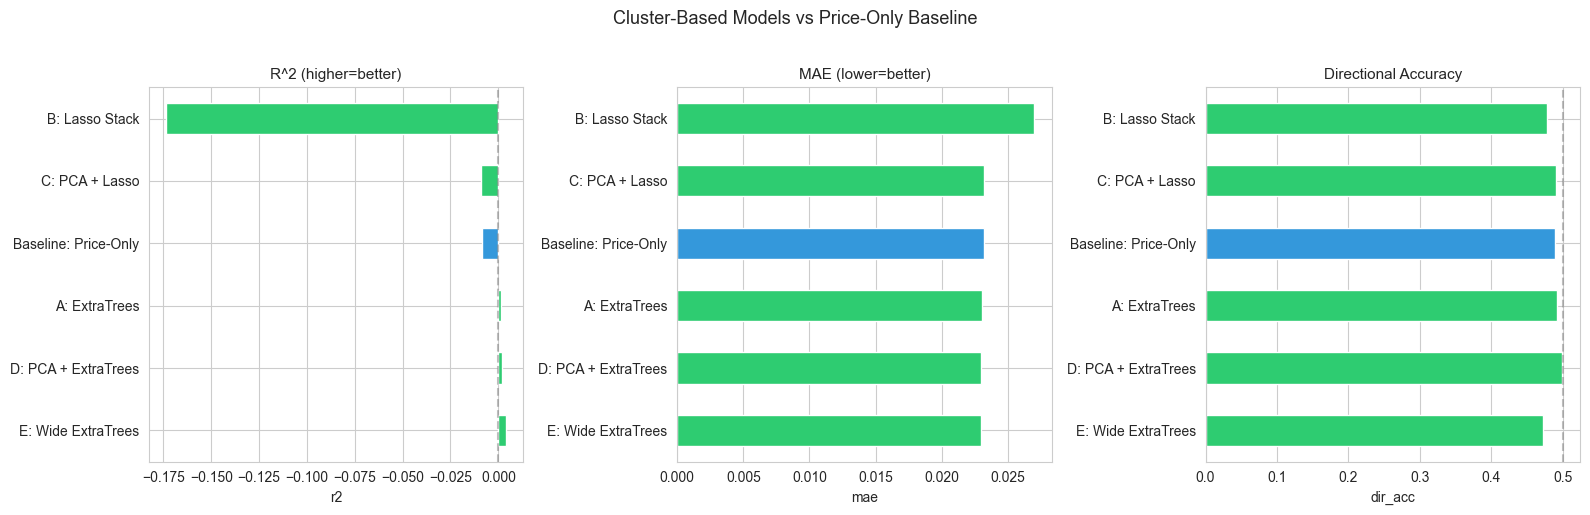

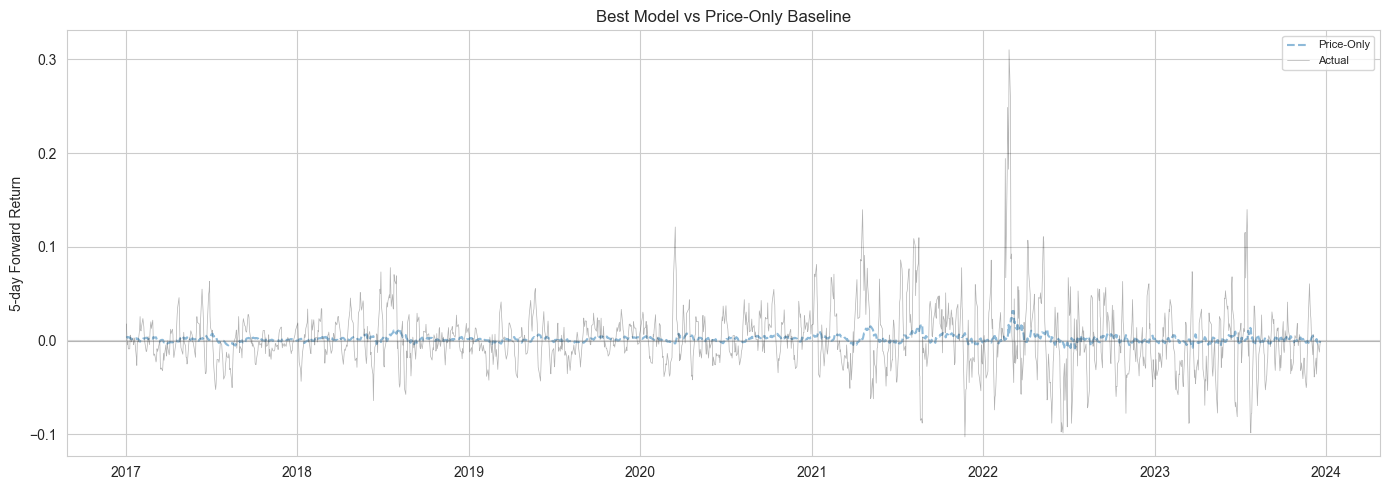

In [57]:
# ============================================================
# Comparison visualisation
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric, title in zip(
    axes, ['r2', 'mae', 'dir_acc'],
    ['R^2 (higher=better)', 'MAE (lower=better)', 'Directional Accuracy']
):
    vals = lb_df[metric]
    colors = ['#2ecc71' if 'Baseline' not in n else '#3498db' for n in vals.index]
    vals.plot.barh(ax=ax, color=colors)
    if metric == 'r2':
        ax.axvline(x=0, color='grey', linestyle='--', alpha=0.5)
    elif metric == 'dir_acc':
        ax.axvline(x=0.5, color='grey', linestyle='--', alpha=0.5)
    ax.set_xlabel(metric)
    ax.set_title(title, fontsize=11)

plt.suptitle('Cluster-Based Models vs Price-Only Baseline', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- Time series of best model vs baseline ---
fig, ax = plt.subplots(figsize=(14, 5))
best_name = lb_df.index[0]

# Find predictions for best model
for name in [best_name]:
    if name in approach_a_results:
        preds = approach_a_results[name]['predictions']
    elif name == 'B: Lasso Stack' and approach_b_result:
        preds = approach_b_result['predictions']
    elif name == 'C: PCA + Ridge' and approach_c_result:
        preds = approach_c_result['predictions']
    else:
        continue
    ax.plot(preds['Date'], preds['y_pred'], label=name, alpha=0.7, linewidth=0.8)

if baseline_result:
    bp = baseline_result['predictions']
    ax.plot(bp['Date'], bp['y_pred'], label='Price-Only', alpha=0.5, linestyle='--')
    ax.plot(bp['Date'], bp['Fwd_Return'], label='Actual', color='black', alpha=0.3, linewidth=0.5)

ax.axhline(y=0, color='grey', alpha=0.3)
ax.set_ylabel('5-day Forward Return')
ax.set_title('Best Model vs Price-Only Baseline')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

In [36]:
# ============================================================
# Per-cluster performance breakdown (Approach A: Ridge)
# ============================================================
if 'C: PCA + ExtraTrees' in approach_a_results:
    print("\nPer-cluster performance (Ridge):")
    for c, metrics in approach_a_results['C: PCA + ExtraTrees']['per_cluster'].items():
        n_members = len(cluster_members.get(c, []))
        countries = {}
        for r in cluster_members.get(c, []):
            cc = r[:2]
            countries[cc] = countries.get(cc, 0) + 1
        country_str = ', '.join(f'{cc}:{n}' for cc, n in sorted(countries.items()))
        print(f"  Cluster {c} ({n_members} regions: {country_str}): "
              f"R2={metrics['r2']:.4f}, Dir={metrics['dir_acc']:.4f}")

Top 2 models for backtesting: ['E: Wide ExtraTrees', 'D: PCA + ExtraTrees']

  E: Wide ExtraTrees: predictions not found, skipping
  D: PCA + ExtraTrees: predictions not found, skipping


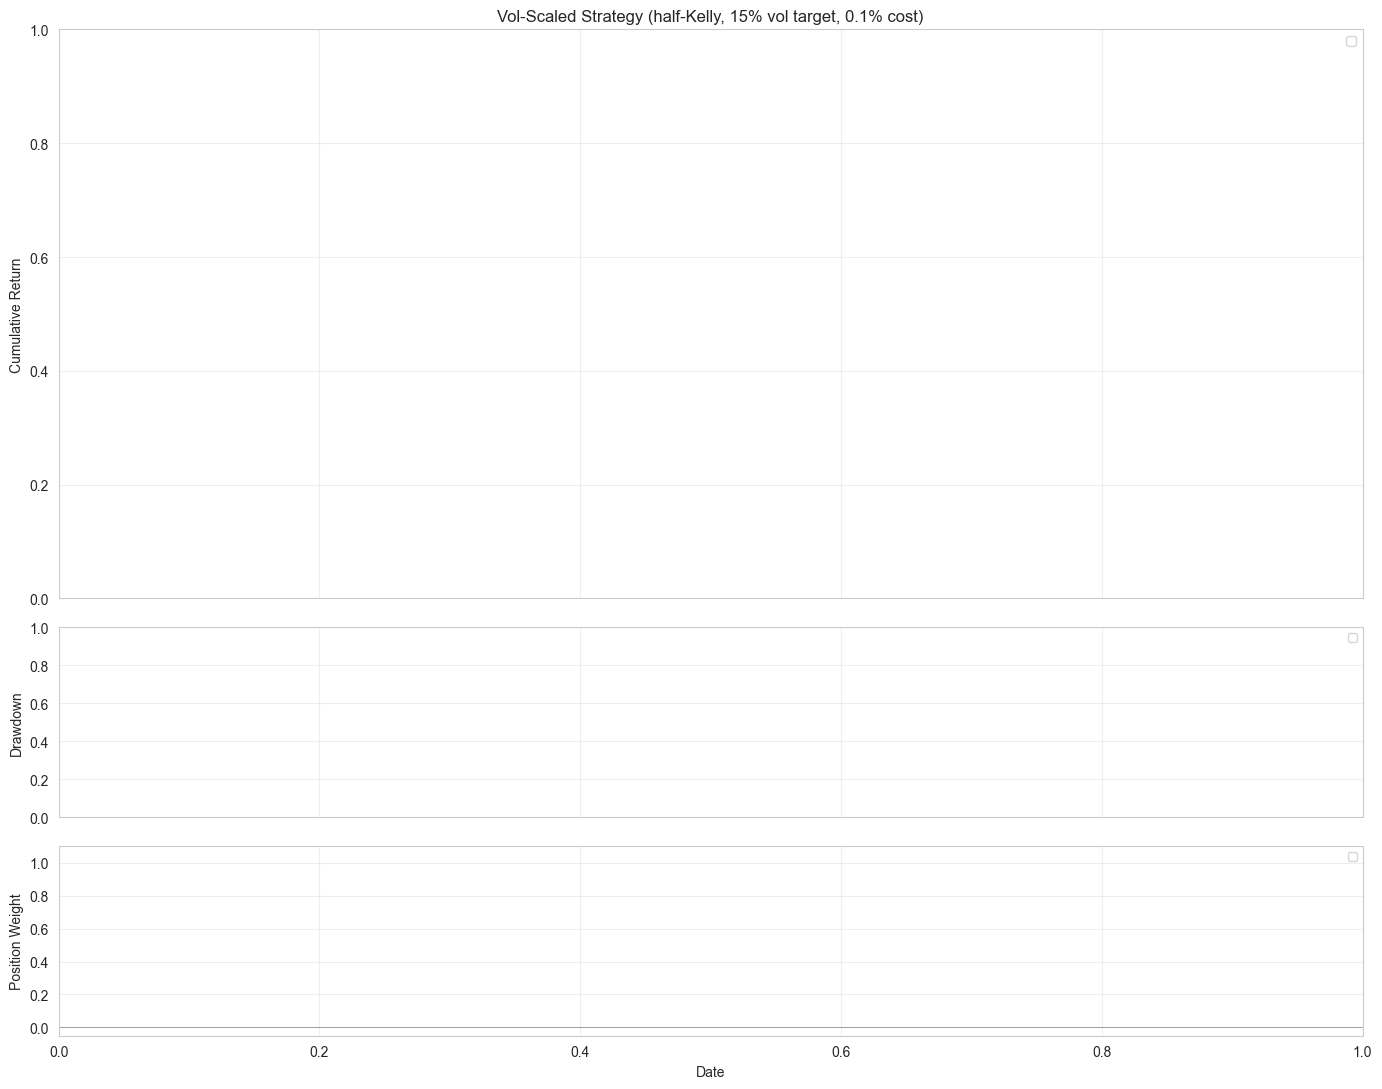

In [58]:
# %% [markdown]
# ---
# ## 7c. Trading Strategy Backtest (Regression Version)
#
# The regression-based strategy exploits three advantages of
# having a continuous predicted return rather than a binary
# direction:
#
# 1. **Volatility scaling** (Moskowitz, Ooi & Pedersen, 2012):
#    Position size is inversely proportional to recent realised
#    volatility. When markets are calm, the strategy sizes up;
#    when markets are volatile, it sizes down.
#
# 2. **Half-Kelly sizing** (Kelly, 1956; Thorp, 2006):
#    The predicted return magnitude determines position weight
#    via the continuous Kelly fraction f* = μ/σ², scaled to
#    half-Kelly for conservatism.
#
# 3. **Adaptive dead-zone** (Lecture 2: bias-variance):
#    The strategy only acts when the predicted return exceeds
#    the model's own recent prediction error — its noise floor.

# %%
# ============================================================
# Trading Strategy — Volatility-Scaled Regression Long/Flat
# ============================================================

TRADE_COST = 0.001
TARGET_VOL = 0.15
VOL_LOOKBACK = 20
KELLY_FRACTION = 0.75
MAX_WEIGHT = 1.0
DEAD_ZONE_FRAC = 0.05

# Pick top 2 models from v4 leaderboard
top2_names = lb_df.index[:2].tolist()
print(f'Top 2 models for backtesting: {top2_names}\n')


def backtest_volscaled(predictions_df, futures_df, trade_cost=0.001,
                       target_vol=0.15, vol_lookback=20,
                       kelly_frac=0.25, max_weight=1.0,
                       dead_zone_frac=0.05,
                       lookback=40, min_hold=3, horizon=5):
    df = predictions_df.merge(
        futures_df[['Date', 'Price']],
        on='Date', how='left'
    ).dropna(subset=['Fwd_Return']).copy().reset_index(drop=True)

    df['rolling_vol'] = df['Fwd_Return'].rolling(vol_lookback, min_periods=10).std() * np.sqrt(252)
    df['rolling_var'] = df['Fwd_Return'].rolling(vol_lookback * 3, min_periods=20).var()

    weights = []
    regimes = []
    dead_zones = []
    past_predictions = []

    for idx in range(len(df)):
        pred_ret = df.loc[idx, 'y_pred']
        actual_return = df.loc[idx, 'Fwd_Return']
        r_vol = df.loc[idx, 'rolling_vol']
        r_var = df.loc[idx, 'rolling_var']

        past_predictions.append((idx, pred_ret, actual_return))

        settled = [(p, a) for (t, p, a) in past_predictions if t <= idx - horizon]
        recent = settled[-lookback:] if len(settled) >= lookback else settled

        if len(recent) >= 10:
            noise_est = np.mean([abs(p - a) for p, a in recent])
            recent_dir_acc = np.mean([1 if (p > 0) == (a > 0) else 0 for p, a in recent])
        else:
            noise_est = 0.01
            recent_dir_acc = 0.50

        dead_zones.append(noise_est)

        if recent_dir_acc >= 0.54:
            regime = 'HOT'
        elif recent_dir_acc <= 0.48:
            regime = 'COLD'
        else:
            regime = 'NEUTRAL'
        regimes.append(regime)

        if pred_ret <= noise_est * dead_zone_frac or np.isnan(r_vol) or r_vol <= 0 or np.isnan(r_var) or r_var <= 0:
            weights.append(0.0)
            continue

        if regime == 'COLD' and (len(weights) == 0 or weights[-1] == 0):
            weights.append(0.0)
            continue

        kelly_weight = kelly_frac * pred_ret / r_var
        vol_scalar = target_vol / r_vol
        raw_weight = kelly_weight * vol_scalar
        final_weight = np.clip(raw_weight, 0.0, max_weight)
        weights.append(final_weight)

    df['weight'] = weights
    df['regime'] = regimes
    df['dead_zone'] = dead_zones

    smoothed = df['weight'].copy()
    hold_counter = 0
    last_nonzero_weight = 0.0
    for idx in range(len(smoothed)):
        if hold_counter > 0:
            smoothed.iloc[idx] = last_nonzero_weight
            hold_counter -= 1
        elif smoothed.iloc[idx] > 0 and (idx == 0 or df['weight'].iloc[idx - 1] == 0):
            last_nonzero_weight = smoothed.iloc[idx]
            hold_counter = min_hold - 1
    df['weight'] = smoothed

    df['position'] = (df['weight'] > 0).astype(float)
    df['strategy_return_gross'] = df['weight'] * df['Fwd_Return']
    df['weight_change'] = df['weight'].diff().abs().fillna(df['weight'].abs())
    df['trade_costs'] = df['weight_change'] * trade_cost
    df['strategy_return'] = df['strategy_return_gross'] - df['trade_costs']
    df['bnh_return'] = df['Fwd_Return']
    df['cum_strategy'] = (1 + df['strategy_return']).cumprod()
    df['cum_bnh'] = (1 + df['bnh_return']).cumprod()

    total_ret = df['cum_strategy'].iloc[-1] - 1
    bnh_ret = df['cum_bnh'].iloc[-1] - 1
    n_trades = ((df['weight'] > 0) & (df['weight'].shift(1).fillna(0) == 0)).sum()
    total_costs = df['trade_costs'].sum()
    n_active = (df['weight'] > 0).sum()
    pct_active = n_active / len(df)
    daily_std = df['strategy_return'].std()
    sharpe = (df['strategy_return'].mean() / daily_std * np.sqrt(252)) if daily_std > 0 else 0
    cum = df['cum_strategy']
    max_dd = ((cum - cum.cummax()) / cum.cummax()).min()
    long_rets = df.loc[df['weight'] > 0, 'strategy_return']
    win_rate = (long_rets > 0).mean() if len(long_rets) > 0 else 0
    flat_days = df[df['weight'] == 0]
    avoided_loss = flat_days['Fwd_Return'].clip(upper=0).sum()
    avg_weight = df.loc[df['weight'] > 0, 'weight'].mean() if n_active > 0 else 0
    realised_vol = df['strategy_return'].std() * np.sqrt(252)
    regime_counts = df['regime'].value_counts()

    return {
        'df': df, 'total_return': total_ret, 'bnh_return': bnh_ret,
        'sharpe': sharpe, 'max_drawdown': max_dd, 'n_trades': n_trades,
        'total_costs': total_costs, 'win_rate': win_rate,
        'pct_active': pct_active, 'regime_counts': regime_counts,
        'avoided_loss': avoided_loss,
        'avg_weight': avg_weight, 'realised_vol': realised_vol,
    }


# ---- Run for top 2 models ----
backtest_results = {}
for name in top2_names:
    # Get predictions from the right source
    if name in approach_a_results:
        preds = approach_a_results[name]['predictions']
    elif name == 'B: Lasso Stack' and approach_b_result:
        preds = approach_b_result['predictions']
    elif name == 'C: PCA + Ridge' and approach_c_result:
        preds = approach_c_result['predictions']
    elif name == 'Baseline: Price-Only' and baseline_result:
        preds = baseline_result['predictions']
    else:
        print(f"  {name}: predictions not found, skipping")
        continue

    bt = backtest_volscaled(preds, futures, trade_cost=TRADE_COST,
                            target_vol=TARGET_VOL,
                            vol_lookback=VOL_LOOKBACK,
                            kelly_frac=KELLY_FRACTION,
                            max_weight=MAX_WEIGHT,
                            dead_zone_frac=DEAD_ZONE_FRAC,
                            horizon=FORECAST_HORIZON)
    backtest_results[name] = bt
    excess = bt['total_return'] - bt['bnh_return']
    print(f"{name}:")
    print(f"  Return: {bt['total_return']:+.2%}  |  B&H: {bt['bnh_return']:+.2%}  |  "
          f"Excess: {excess:+.2%}")
    print(f"  Sharpe: {bt['sharpe']:.2f}  |  MaxDD: {bt['max_drawdown']:.2%}  |  "
          f"Win: {bt['win_rate']:.1%}")
    print(f"  Long: {bt['pct_active']:.0%} of days  |  Flat: {1-bt['pct_active']:.0%} of days")
    print(f"  Avg weight when long: {bt['avg_weight']:.2f}  |  "
          f"Realised vol: {bt['realised_vol']:.1%}")
    print(f"  Trades: {bt['n_trades']}  |  Costs: {bt['total_costs']:.4f}")
    print(f"  Regime: {dict(bt['regime_counts'])}")
    print()

# ---- Equity curves ----
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1, 1]})

ax = axes[0]
colors_bt = ['#e74c3c', '#2ecc71']
bnh_plotted = False
for j, name in enumerate(backtest_results.keys()):
    bt = backtest_results[name]
    df_bt = bt['df']
    ax.plot(df_bt['Date'], df_bt['cum_strategy'], label=name,
            color=colors_bt[j % len(colors_bt)], linewidth=1.5)
    if not bnh_plotted:
        ax.plot(df_bt['Date'], df_bt['cum_bnh'], label='Buy & Hold',
                color='black', linewidth=1, linestyle='--', alpha=0.7)
        bnh_plotted = True
ax.axhline(1.0, color='grey', linestyle=':', alpha=0.5)
ax.set_ylabel('Cumulative Return')
ax.set_title(f'Vol-Scaled Strategy (half-Kelly, {TARGET_VOL:.0%} vol target, '
             f'{TRADE_COST*100}% cost)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
for j, name in enumerate(backtest_results.keys()):
    bt = backtest_results[name]
    df_bt = bt['df']
    cum = df_bt['cum_strategy']
    dd = (cum - cum.cummax()) / cum.cummax()
    ax2.fill_between(df_bt['Date'], dd, 0, alpha=0.3,
                     color=colors_bt[j % len(colors_bt)], label=name)
ax2.set_ylabel('Drawdown')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

ax3 = axes[2]
for j, name in enumerate(backtest_results.keys()):
    bt = backtest_results[name]
    df_bt = bt['df']
    ax3.plot(df_bt['Date'], df_bt['weight'],
             color=colors_bt[j % len(colors_bt)], alpha=0.6, linewidth=0.8, label=name)
ax3.set_ylabel('Position Weight')
ax3.set_xlabel('Date')
ax3.set_ylim(-0.05, MAX_WEIGHT + 0.1)
ax3.axhline(0, color='grey', linewidth=0.5)
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Top 2 models for regime sampling: ['A: ExtraTrees', 'Baseline: Price-Only']

Test period: 2017-01-02 to 2023-12-20
Generated 40 overlapping 0.5-year windows (step = 2 months)

  A: ExtraTrees: 40 windows evaluated
  Baseline: Price-Only: 40 windows evaluated

REGIME-SAMPLING RESULTS (Vol-Scaled Regression Strategy)

────────────────────────────────────────────────────────────────────────────────
  A: ExtraTrees
────────────────────────────────────────────────────────────────────────────────
  Windows: 40
  Strategy beats B&H: 22/40 (55%)
  Median excess return:  +10.86%
  Mean excess return:    -65.28%
  Mean Sharpe:           0.97
  Worst max drawdown:    -38.95%
  Mean win rate:         50.7%
  Mean % time long:      33%
  Mean avg weight:       0.75
  Mean strategy vol:     19.2%
  Mean B&H vol:          47.7%
  Mean vol reduction:    60%

  Per-regime breakdown:
    Bear / High-Vol       n=13  med_excess=+31.76%  beats_bnh=100%  sharpe=-0.96
    Bear / Mid-Vol        n= 3  med_exce

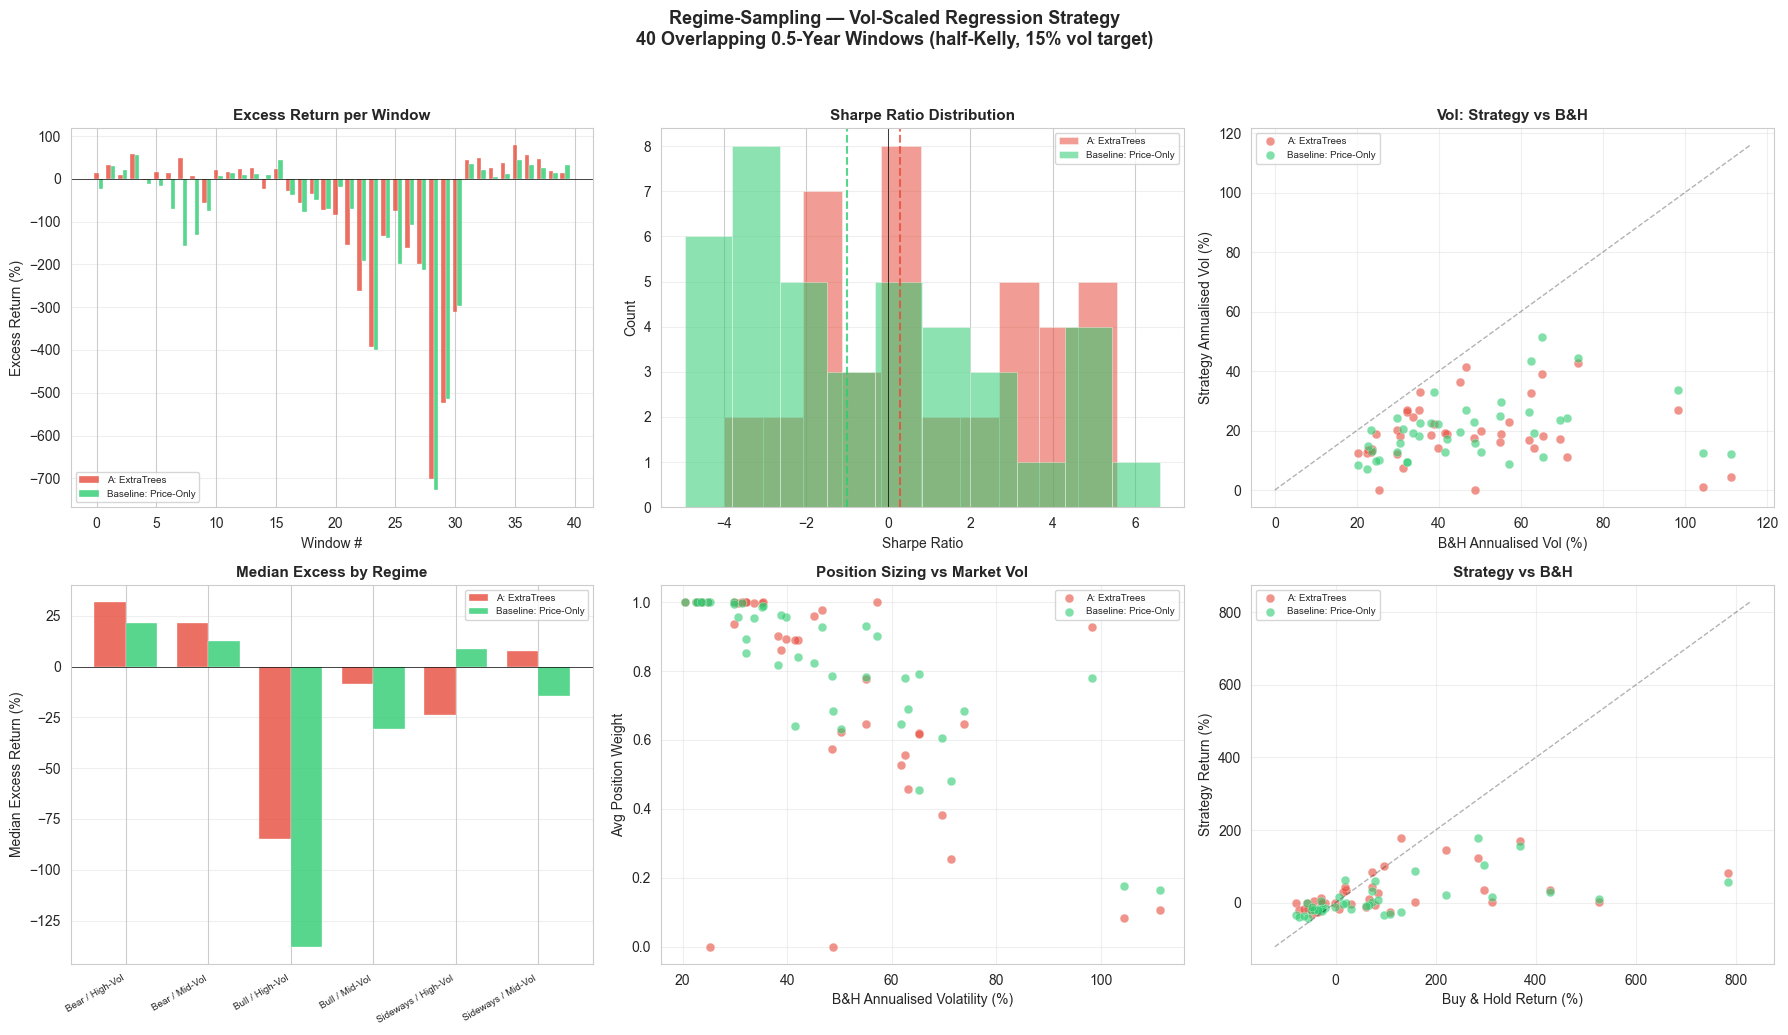

In [62]:
# ============================================================
# Regime-Sampling Backtest (Volatility-Scaled Regression)
# ============================================================

from datetime import timedelta
from collections import defaultdict

WINDOW_YEARS = 0.5
STEP_MONTHS = 2
MIN_DAYS = 100

top2_names = lb_df.index[:2].tolist()
print(f"Top 2 models for regime sampling: {top2_names}\n")

# Helper to get predictions for any model name
def get_predictions(name):
    if name in approach_a_results:
        return approach_a_results[name]['predictions']
    elif name == 'B: Lasso Stack' and approach_b_result:
        return approach_b_result['predictions']
    elif name == 'C: PCA + Ridge' and approach_c_result:
        return approach_c_result['predictions']
    elif name == 'Baseline: Price-Only' and baseline_result:
        return baseline_result['predictions']
    return None

# Generate windows
sample_preds = get_predictions(top2_names[0])
test_date_min = sample_preds['Date'].min()
test_date_max = sample_preds['Date'].max()

windows = []
win_start = test_date_min
while win_start + timedelta(days=WINDOW_YEARS * 365) <= test_date_max + timedelta(days=30):
    win_end = win_start + timedelta(days=WINDOW_YEARS * 365)
    windows.append((win_start, min(win_end, test_date_max)))
    win_start += pd.DateOffset(months=STEP_MONTHS)

print(f"Test period: {test_date_min.date()} to {test_date_max.date()}")
print(f"Generated {len(windows)} overlapping {WINDOW_YEARS}-year windows "
      f"(step = {STEP_MONTHS} months)\n")

# Run vol-scaled backtest on each window
regime_results = defaultdict(list)

for model_name in top2_names:
    preds_full = get_predictions(model_name)
    if preds_full is None:
        print(f"  {model_name}: no predictions found, skipping")
        continue

    preds_full = preds_full.copy()

    for i, (ws, we) in enumerate(windows):
        mask = (preds_full['Date'] >= ws) & (preds_full['Date'] <= we)
        preds_window = preds_full[mask].reset_index(drop=True)

        if len(preds_window) < MIN_DAYS:
            continue

        bt = backtest_volscaled(
            preds_window, futures,
            trade_cost=TRADE_COST,
            target_vol=TARGET_VOL,
            vol_lookback=VOL_LOOKBACK,
            kelly_frac=KELLY_FRACTION,
            max_weight=MAX_WEIGHT,
            dead_zone_frac=DEAD_ZONE_FRAC,
            horizon=FORECAST_HORIZON
        )

        bnh_daily_std = bt['df']['Fwd_Return'].std()
        bnh_ann_vol = bnh_daily_std * np.sqrt(252)
        bnh_total = bt['bnh_return']

        if bnh_ann_vol > 0.30:
            vol_label = 'High-Vol'
        elif bnh_ann_vol < 0.18:
            vol_label = 'Low-Vol'
        else:
            vol_label = 'Mid-Vol'

        if bnh_total > 0.15:
            trend_label = 'Bull'
        elif bnh_total < -0.10:
            trend_label = 'Bear'
        else:
            trend_label = 'Sideways'

        regime_results[model_name].append({
            'window': f"{ws.date()} → {we.date()}",
            'start': ws, 'end': we,
            'n_days': len(bt['df']),
            'strategy_ret': bt['total_return'],
            'bnh_ret': bt['bnh_return'],
            'excess': bt['total_return'] - bt['bnh_return'],
            'sharpe': bt['sharpe'],
            'max_dd': bt['max_drawdown'],
            'win_rate': bt['win_rate'],
            'pct_long': bt['pct_active'],
            'avg_weight': bt['avg_weight'],
            'n_trades': bt['n_trades'],
            'strat_ann_vol': bt['realised_vol'],
            'bnh_ann_vol': bnh_ann_vol,
            'regime': f"{trend_label} / {vol_label}",
        })

    print(f"  {model_name}: {len(regime_results[model_name])} windows evaluated")

# Summary
summary_dfs = {}
for model_name in top2_names:
    if model_name not in regime_results:
        continue
    df = pd.DataFrame(regime_results[model_name])
    df = df.sort_values('start').reset_index(drop=True)
    # df = df[df['excess'].abs() <= 10].reset_index(drop=True)
    summary_dfs[model_name] = df

print("\n" + "="*80)
print("REGIME-SAMPLING RESULTS (Vol-Scaled Regression Strategy)")
print("="*80)

for model_name in summary_dfs:
    df = summary_dfs[model_name]
    print(f"\n{'─'*80}")
    print(f"  {model_name}")
    print(f"{'─'*80}")
    print(f"  Windows: {len(df)}")
    print(f"  Strategy beats B&H: {(df['excess'] > 0).sum()}/{len(df)} "
          f"({(df['excess'] > 0).mean():.0%})")
    print(f"  Median excess return:  {df['excess'].median():+.2%}")
    print(f"  Mean excess return:    {df['excess'].mean():+.2%}")
    print(f"  Mean Sharpe:           {df['sharpe'].mean():.2f}")
    print(f"  Worst max drawdown:    {df['max_dd'].min():.2%}")
    print(f"  Mean win rate:         {df['win_rate'].mean():.1%}")
    print(f"  Mean % time long:      {df['pct_long'].mean():.0%}")
    print(f"  Mean avg weight:       {df['avg_weight'].mean():.2f}")
    print(f"  Mean strategy vol:     {df['strat_ann_vol'].mean():.1%}")
    print(f"  Mean B&H vol:          {df['bnh_ann_vol'].mean():.1%}")
    if df['bnh_ann_vol'].mean() > 0:
        print(f"  Mean vol reduction:    "
              f"{(1 - df['strat_ann_vol'].mean() / df['bnh_ann_vol'].mean()):.0%}")

    print(f"\n  Per-regime breakdown:")
    for regime in sorted(df['regime'].unique()):
        sub = df[df['regime'] == regime]
        print(f"    {regime:20s}  n={len(sub):2d}  "
              f"med_excess={sub['excess'].median():+.2%}  "
              f"beats_bnh={sub['excess'].gt(0).mean():.0%}  "
              f"sharpe={sub['sharpe'].mean():.2f}")

# Full window table
for model_name in summary_dfs:
    df = summary_dfs[model_name]
    print(f"\n{'='*80}")
    print(f"  {model_name} — All Windows")
    print(f"{'='*80}")
    display_cols = ['window', 'regime', 'strategy_ret', 'bnh_ret',
                    'excess', 'sharpe', 'max_dd', 'win_rate',
                    'pct_long', 'avg_weight', 'strat_ann_vol', 'bnh_ann_vol']
    print(df[display_cols].to_string(
        index=False,
        formatters={
            'strategy_ret':  '{:+.2%}'.format,
            'bnh_ret':       '{:+.2%}'.format,
            'excess':        '{:+.2%}'.format,
            'sharpe':        '{:.2f}'.format,
            'max_dd':        '{:.2%}'.format,
            'win_rate':      '{:.1%}'.format,
            'pct_long':      '{:.0%}'.format,
            'avg_weight':    '{:.2f}'.format,
            'strat_ann_vol': '{:.1%}'.format,
            'bnh_ann_vol':   '{:.1%}'.format,
        }
    ))

# Visualisation
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
model_colors = {}
color_list = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
for j, name in enumerate(summary_dfs.keys()):
    model_colors[name] = color_list[j % len(color_list)]

ax = axes[0, 0]
bar_w = 0.38
for j, name in enumerate(summary_dfs.keys()):
    df = summary_dfs[name]
    vals = df['excess'].values
    ax.bar(np.arange(len(vals)) + j * bar_w, vals * 100, bar_w,
           label=name, color=model_colors[name], alpha=0.8,
           edgecolor='white', linewidth=0.3)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Excess Return (%)')
ax.set_title('Excess Return per Window', fontsize=11, fontweight='bold')
ax.set_xlabel('Window #')
ax.legend(fontsize=7)
ax.grid(axis='y', alpha=0.3)

ax = axes[0, 1]
for name in summary_dfs:
    df = summary_dfs[name]
    ax.hist(df['sharpe'], bins=10, alpha=0.55, label=name,
            color=model_colors[name], edgecolor='white', linewidth=0.5)
    ax.axvline(df['sharpe'].median(), color=model_colors[name],
               linestyle='--', linewidth=1.5, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Sharpe Ratio')
ax.set_ylabel('Count')
ax.set_title('Sharpe Ratio Distribution', fontsize=11, fontweight='bold')
ax.legend(fontsize=7)
ax.grid(axis='y', alpha=0.3)

ax = axes[0, 2]
for name in summary_dfs:
    df = summary_dfs[name]
    ax.scatter(df['bnh_ann_vol'] * 100, df['strat_ann_vol'] * 100,
               alpha=0.6, s=40, color=model_colors[name], label=name,
               edgecolors='white', linewidth=0.3)
lims = [0, max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'k--', alpha=0.3, linewidth=1)
ax.set_xlabel('B&H Annualised Vol (%)')
ax.set_ylabel('Strategy Annualised Vol (%)')
ax.set_title('Vol: Strategy vs B&H', fontsize=11, fontweight='bold')
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

ax = axes[1, 0]
all_regimes = sorted(set(
    r for name in summary_dfs for r in summary_dfs[name]['regime'].unique()
))
x_reg = np.arange(len(all_regimes))
for j, name in enumerate(summary_dfs.keys()):
    df = summary_dfs[name]
    medians = [df[df['regime'] == r]['excess'].median() if r in df['regime'].values else 0
               for r in all_regimes]
    ax.bar(x_reg + j * bar_w, [m * 100 for m in medians], bar_w,
           label=name, color=model_colors[name], alpha=0.8,
           edgecolor='white', linewidth=0.3)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticks(x_reg + bar_w / 2)
ax.set_xticklabels(all_regimes, fontsize=7, rotation=30, ha='right')
ax.set_ylabel('Median Excess Return (%)')
ax.set_title('Median Excess by Regime', fontsize=11, fontweight='bold')
ax.legend(fontsize=7)
ax.grid(axis='y', alpha=0.3)

ax = axes[1, 1]
for name in summary_dfs:
    df = summary_dfs[name]
    ax.scatter(df['bnh_ann_vol'] * 100, df['avg_weight'],
               alpha=0.6, s=40, color=model_colors[name], label=name,
               edgecolors='white', linewidth=0.3)
ax.set_xlabel('B&H Annualised Volatility (%)')
ax.set_ylabel('Avg Position Weight')
ax.set_title('Position Sizing vs Market Vol', fontsize=11, fontweight='bold')
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

ax = axes[1, 2]
for name in summary_dfs:
    df = summary_dfs[name]
    ax.scatter(df['bnh_ret'] * 100, df['strategy_ret'] * 100,
               alpha=0.6, s=40, color=model_colors[name], label=name,
               edgecolors='white', linewidth=0.3)
lims = ax.get_xlim()
ax.plot(lims, lims, 'k--', alpha=0.3, linewidth=1)
ax.set_xlabel('Buy & Hold Return (%)')
ax.set_ylabel('Strategy Return (%)')
ax.set_title('Strategy vs B&H', fontsize=11, fontweight='bold')
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

fig.suptitle(f'Regime-Sampling — Vol-Scaled Regression Strategy\n'
             f'{len(windows)} Overlapping {WINDOW_YEARS}-Year Windows '
             f'(half-Kelly, {TARGET_VOL:.0%} vol target)',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()